STEP 1: Collecting data from all galaxies for HII regions...
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_*-binned analysis
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857

STEP 2: Defining 8 Σ_* bins with fixed boundaries

Σ_* bins:
  Number of bins: 8

8 Σ_* bins (fixed):
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 3: Creating Z_gas-Σ_SFR plots for 8 Σ_* bins

Using uniform y-axis range: 8.0 to 9.3

Processing D16 calibration for HII regions:
  HII D16 range: 7.906 to 9.229
  Total valid bins: 6

Processing PG16 calibration for HII regions:
  HII PG16 range: 7.645 to 

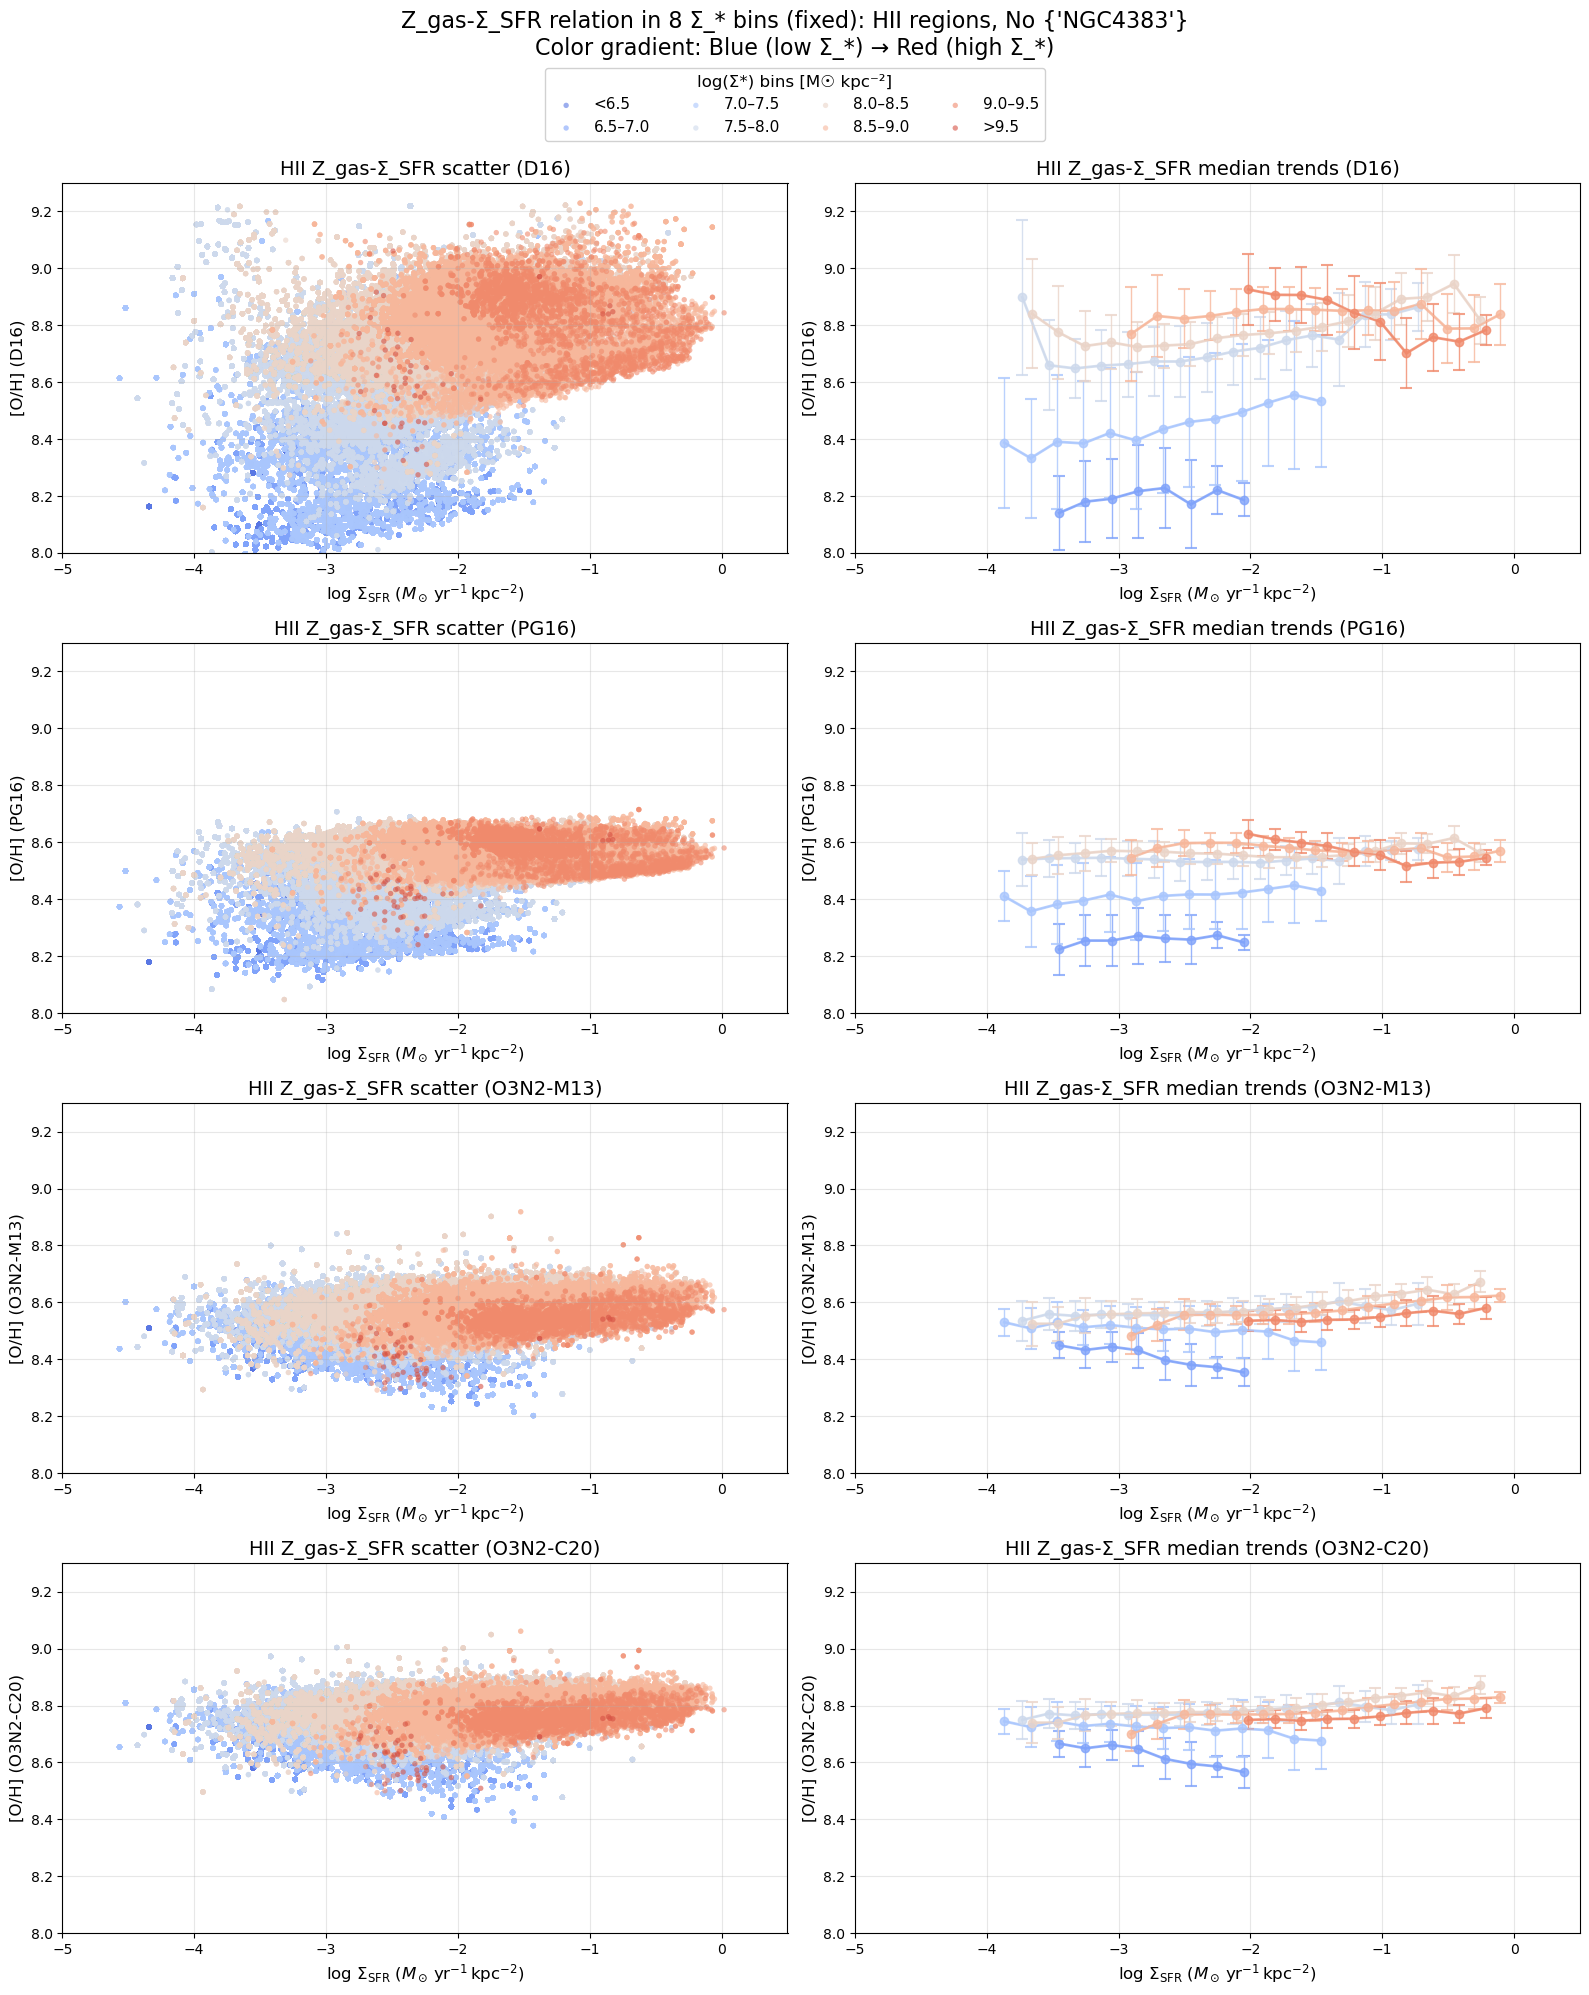


COMPLETED: 8-bin Σ_* analysis for Z_gas-Σ_SFR relation (fixed bins)
Successfully created combined 4x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Bin summary (8 fixed Σ_* bins):
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: Z_gas-Σ_SFR relation in 8 Σ_* bins - HII regions only
# 4 rows x 2 columns: Each row shows 1 indicator (scatter on left, median on right)
# 4 calibrations: D16, PG16, O3N2-M13, O3N2-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in SFR bins - only keep bins with >= 20 unique datapoints"""
    # Define SFR bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    sfr_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    sfr_bin_centers = (sfr_bin_edges[:-1] + sfr_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select data in this SFR bin
        in_sfr_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_sfr_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(sfr_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from Σ_*-binned analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load all data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
         oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_* bins with fixed boundaries (same as 2x2 Z_gas-Σ_SFR code)
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 Σ_* bins with fixed boundaries")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, +inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels (same as bin_labels_sigmaM in reference code)
bin_labels = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
 ]

print(f"\n8 Σ_* bins (fixed):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins))

# ==============================================================================
# STEP 3: Create Z_gas-Σ_SFR plots ([O/H] vs Σ_SFR in different Σ_* bins)
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Creating Z_gas-Σ_SFR plots for 8 Σ_* bins")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 4 rows x 2 columns 
# Each row contains 1 indicator: column 0 for scatter, column 1 for median trends
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Data for each calibration
calibrations = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

# Create legend handles (will be populated during first row)
legend_handles = []
legend_labels = []

# Process each row (1 calibration per row)
for row_idx, (oh_data_HII, calib_name_HII) in enumerate(calibrations):
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    
    # Column 0: Scatter plot, Column 1: Median trends
    ax_scatter = axes[row_idx, 0]
    ax_median = axes[row_idx, 1]
    
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    
    # Plot each Σ_* bin
    valid_bins = 0
    
    for i in range(n_bins):
        # HII regions processing with fixed Σ_* bins
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
        
        n_pixels_HII = np.sum(in_bin_HII)
        
        if n_pixels_HII >= 10:  # Process bins with enough pixels
            # Get data for this bin - NOW: x=Σ_SFR, y=[O/H]
            x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
            y_bin_HII = oh_data_HII[in_bin_HII]
            
            # Scatter plot
            scatter_hii = ax_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                 edgecolors='none', rasterized=True)
            
            # Collect legend info only from first row
            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter_hii)
                legend_labels.append(bin_labels[i])
            
            # Median trends
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
            
            if len(sfr_centers_HII) > 0:
                ax_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                           color=colors[i], marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                               [medians_HII[j], medians_HII[j + 1]], 
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins += 1
    
    # Format scatter plot
    ax_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_scatter.set_title(f'HII Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_xlim(-5.0, 0.5)
    ax_scatter.set_ylim(common_ylim)
    
    # Format median trends plot
    ax_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_median.set_title(f'HII Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
    ax_median.grid(True, alpha=0.3)
    ax_median.set_xlim(-5.0, 0.5)
    ax_median.set_ylim(common_ylim)
    
    print(f"  Total valid bins: {valid_bins}")

# Add overall title and adjust layout
fig.suptitle(f'Z_gas-Σ_SFR relation in 8 Σ_* bins (fixed): HII regions, No {excluded_galaxies}\n' + 
             f'Color gradient: Blue (low Σ_*) → Red (high Σ_*)', 
             fontsize=16, y=0.995)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.97),
          ncol=4, fontsize=11, framealpha=0.9, 
          title='log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle and legend
# plt.savefig('Combined_Zgas_SigmaSFR_HII_8bins_fixed_4x2grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_Zgas_SigmaSFR_HII_8bins_fixed_4x2grid.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: 8-bin Σ_* analysis for Z_gas-Σ_SFR relation (fixed bins)")
print("="*80)
print(f"Successfully created combined 4x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nBin summary (8 fixed Σ_* bins):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-M13
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


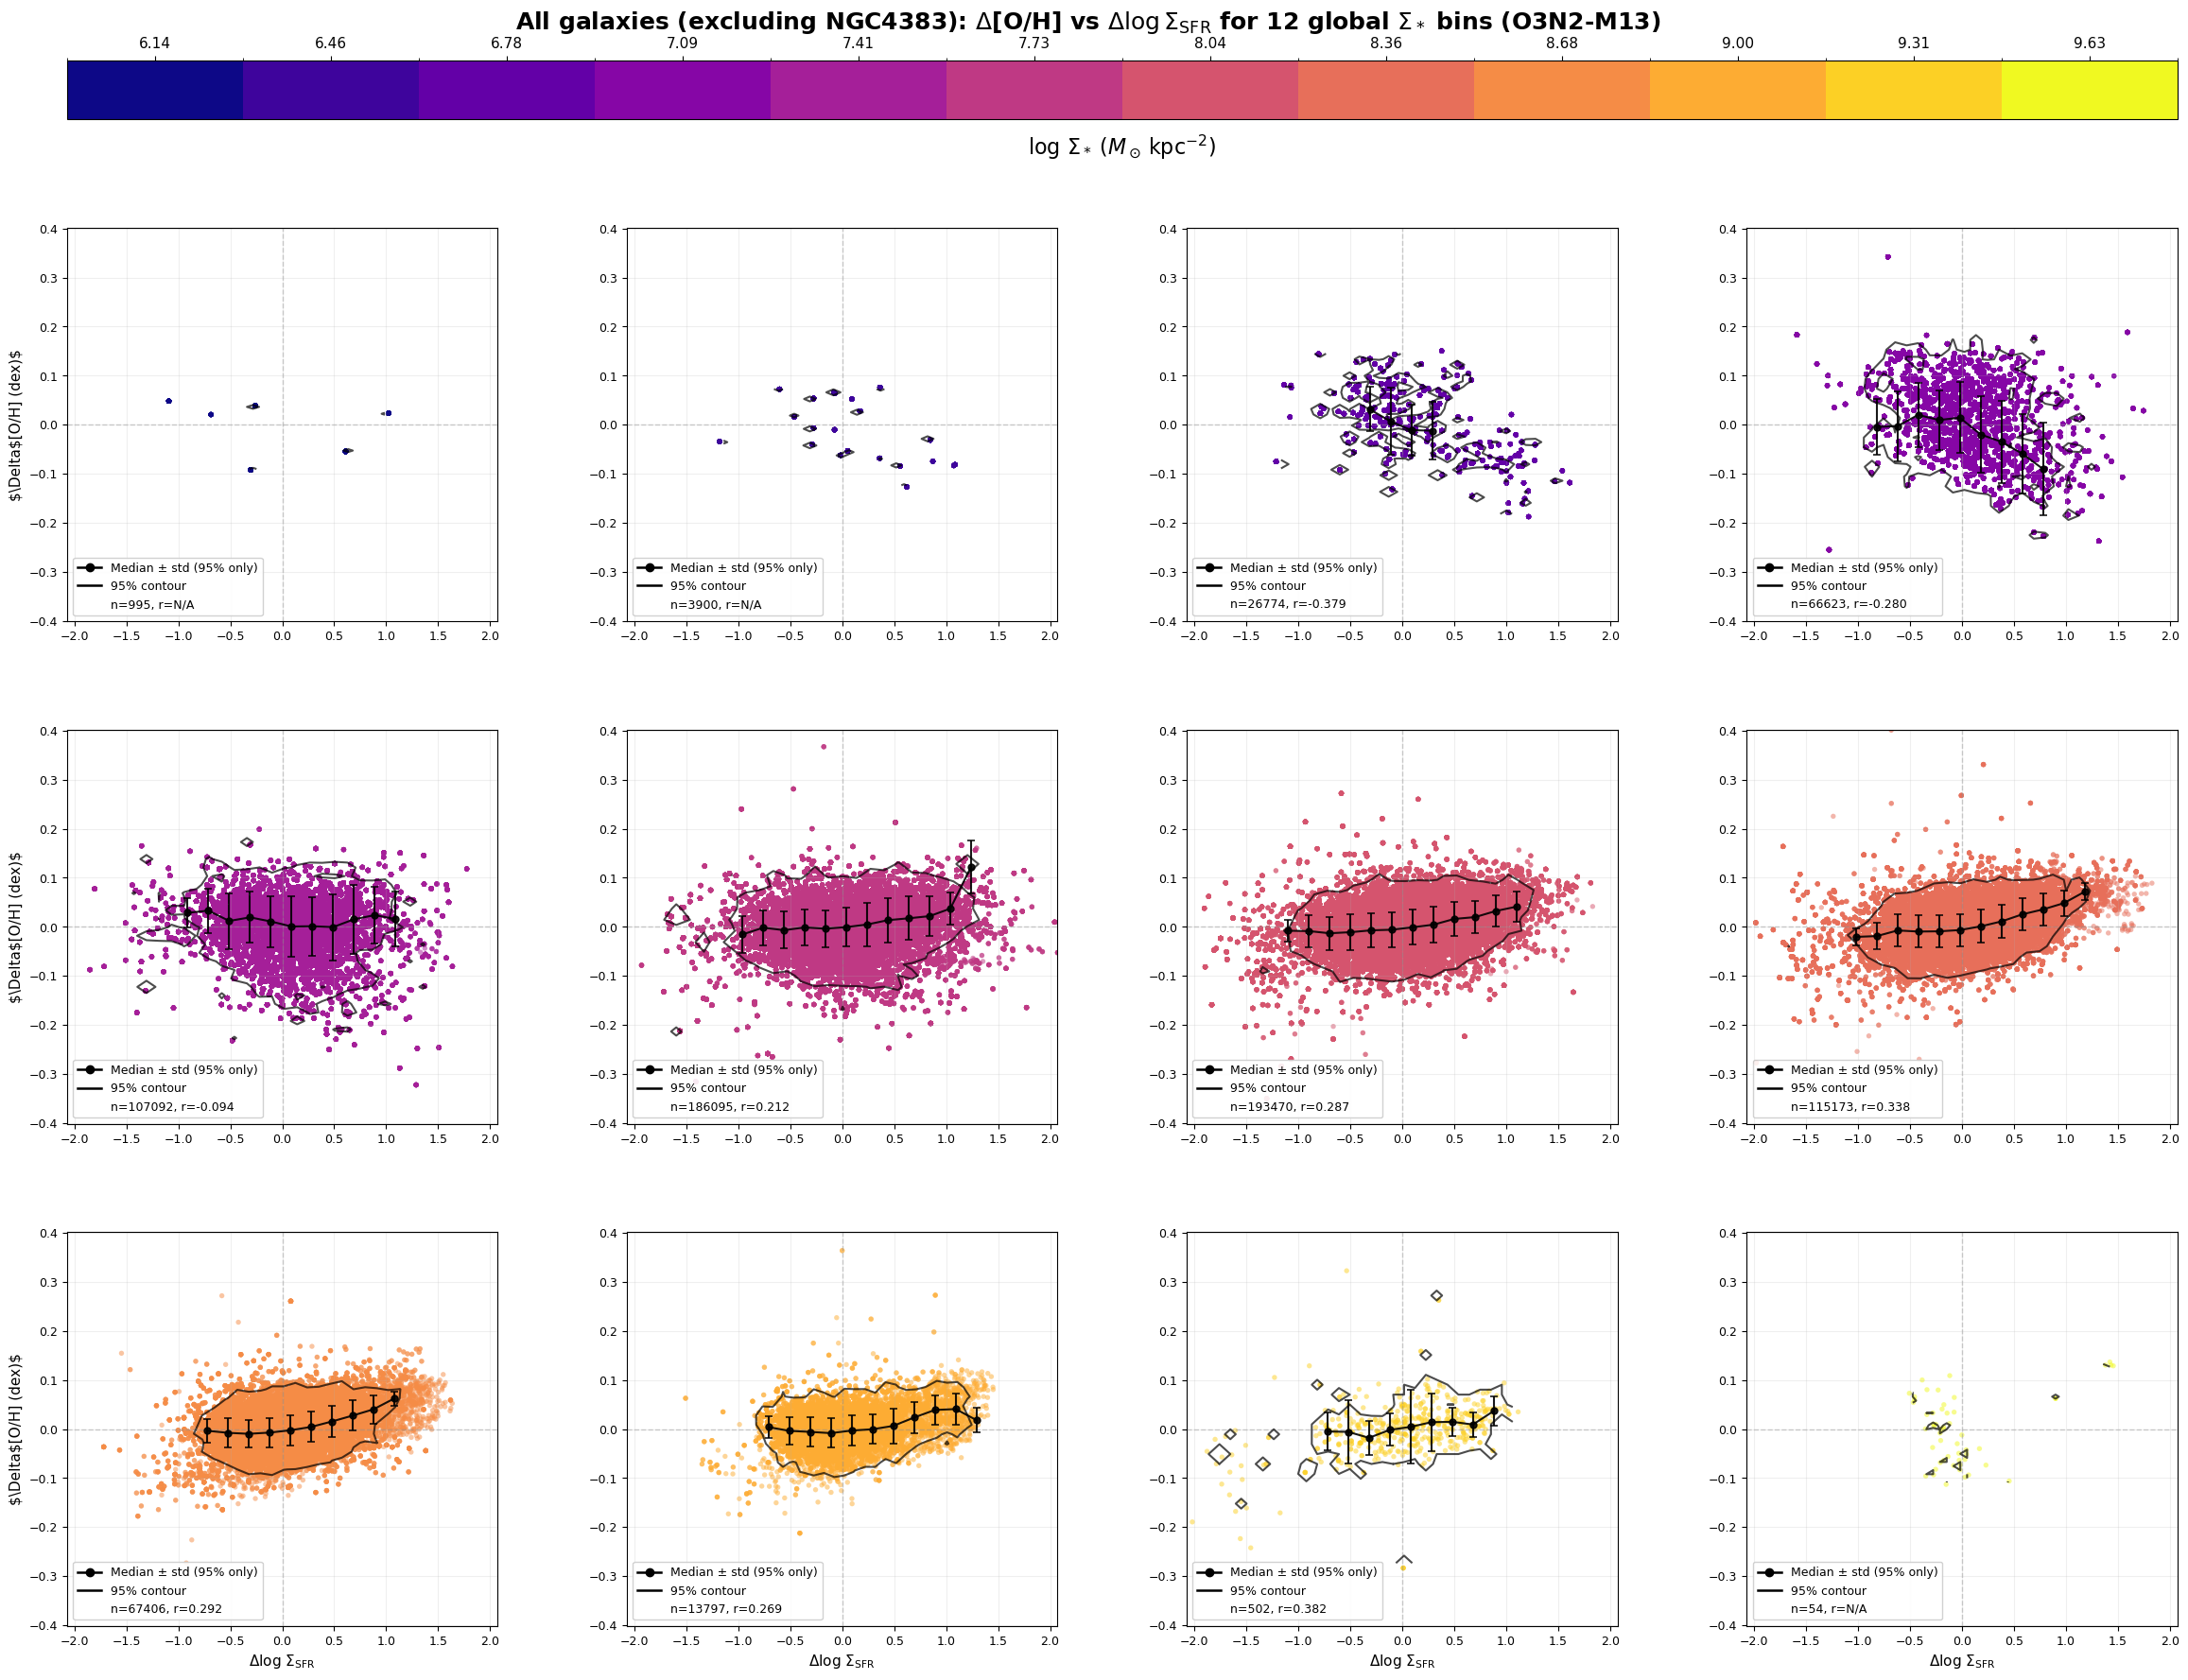

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-M13.


In [2]:
# ------------------------------------------------------------------
# Cell 3: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Pearson r uses same 95% contour + trend definition as Cell 2
# This cell uses the O3N2-M13 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-M13)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-M13 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-M13")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_o3n2_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Pearson r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Pearson r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'r={pearson_r:.3f}'
                except Exception:
                    pearson_r, pearson_p = np.nan, np.nan
                    r_label = 'r=N/A'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (O3N2-M13)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-M13.")

Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383) using D16
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


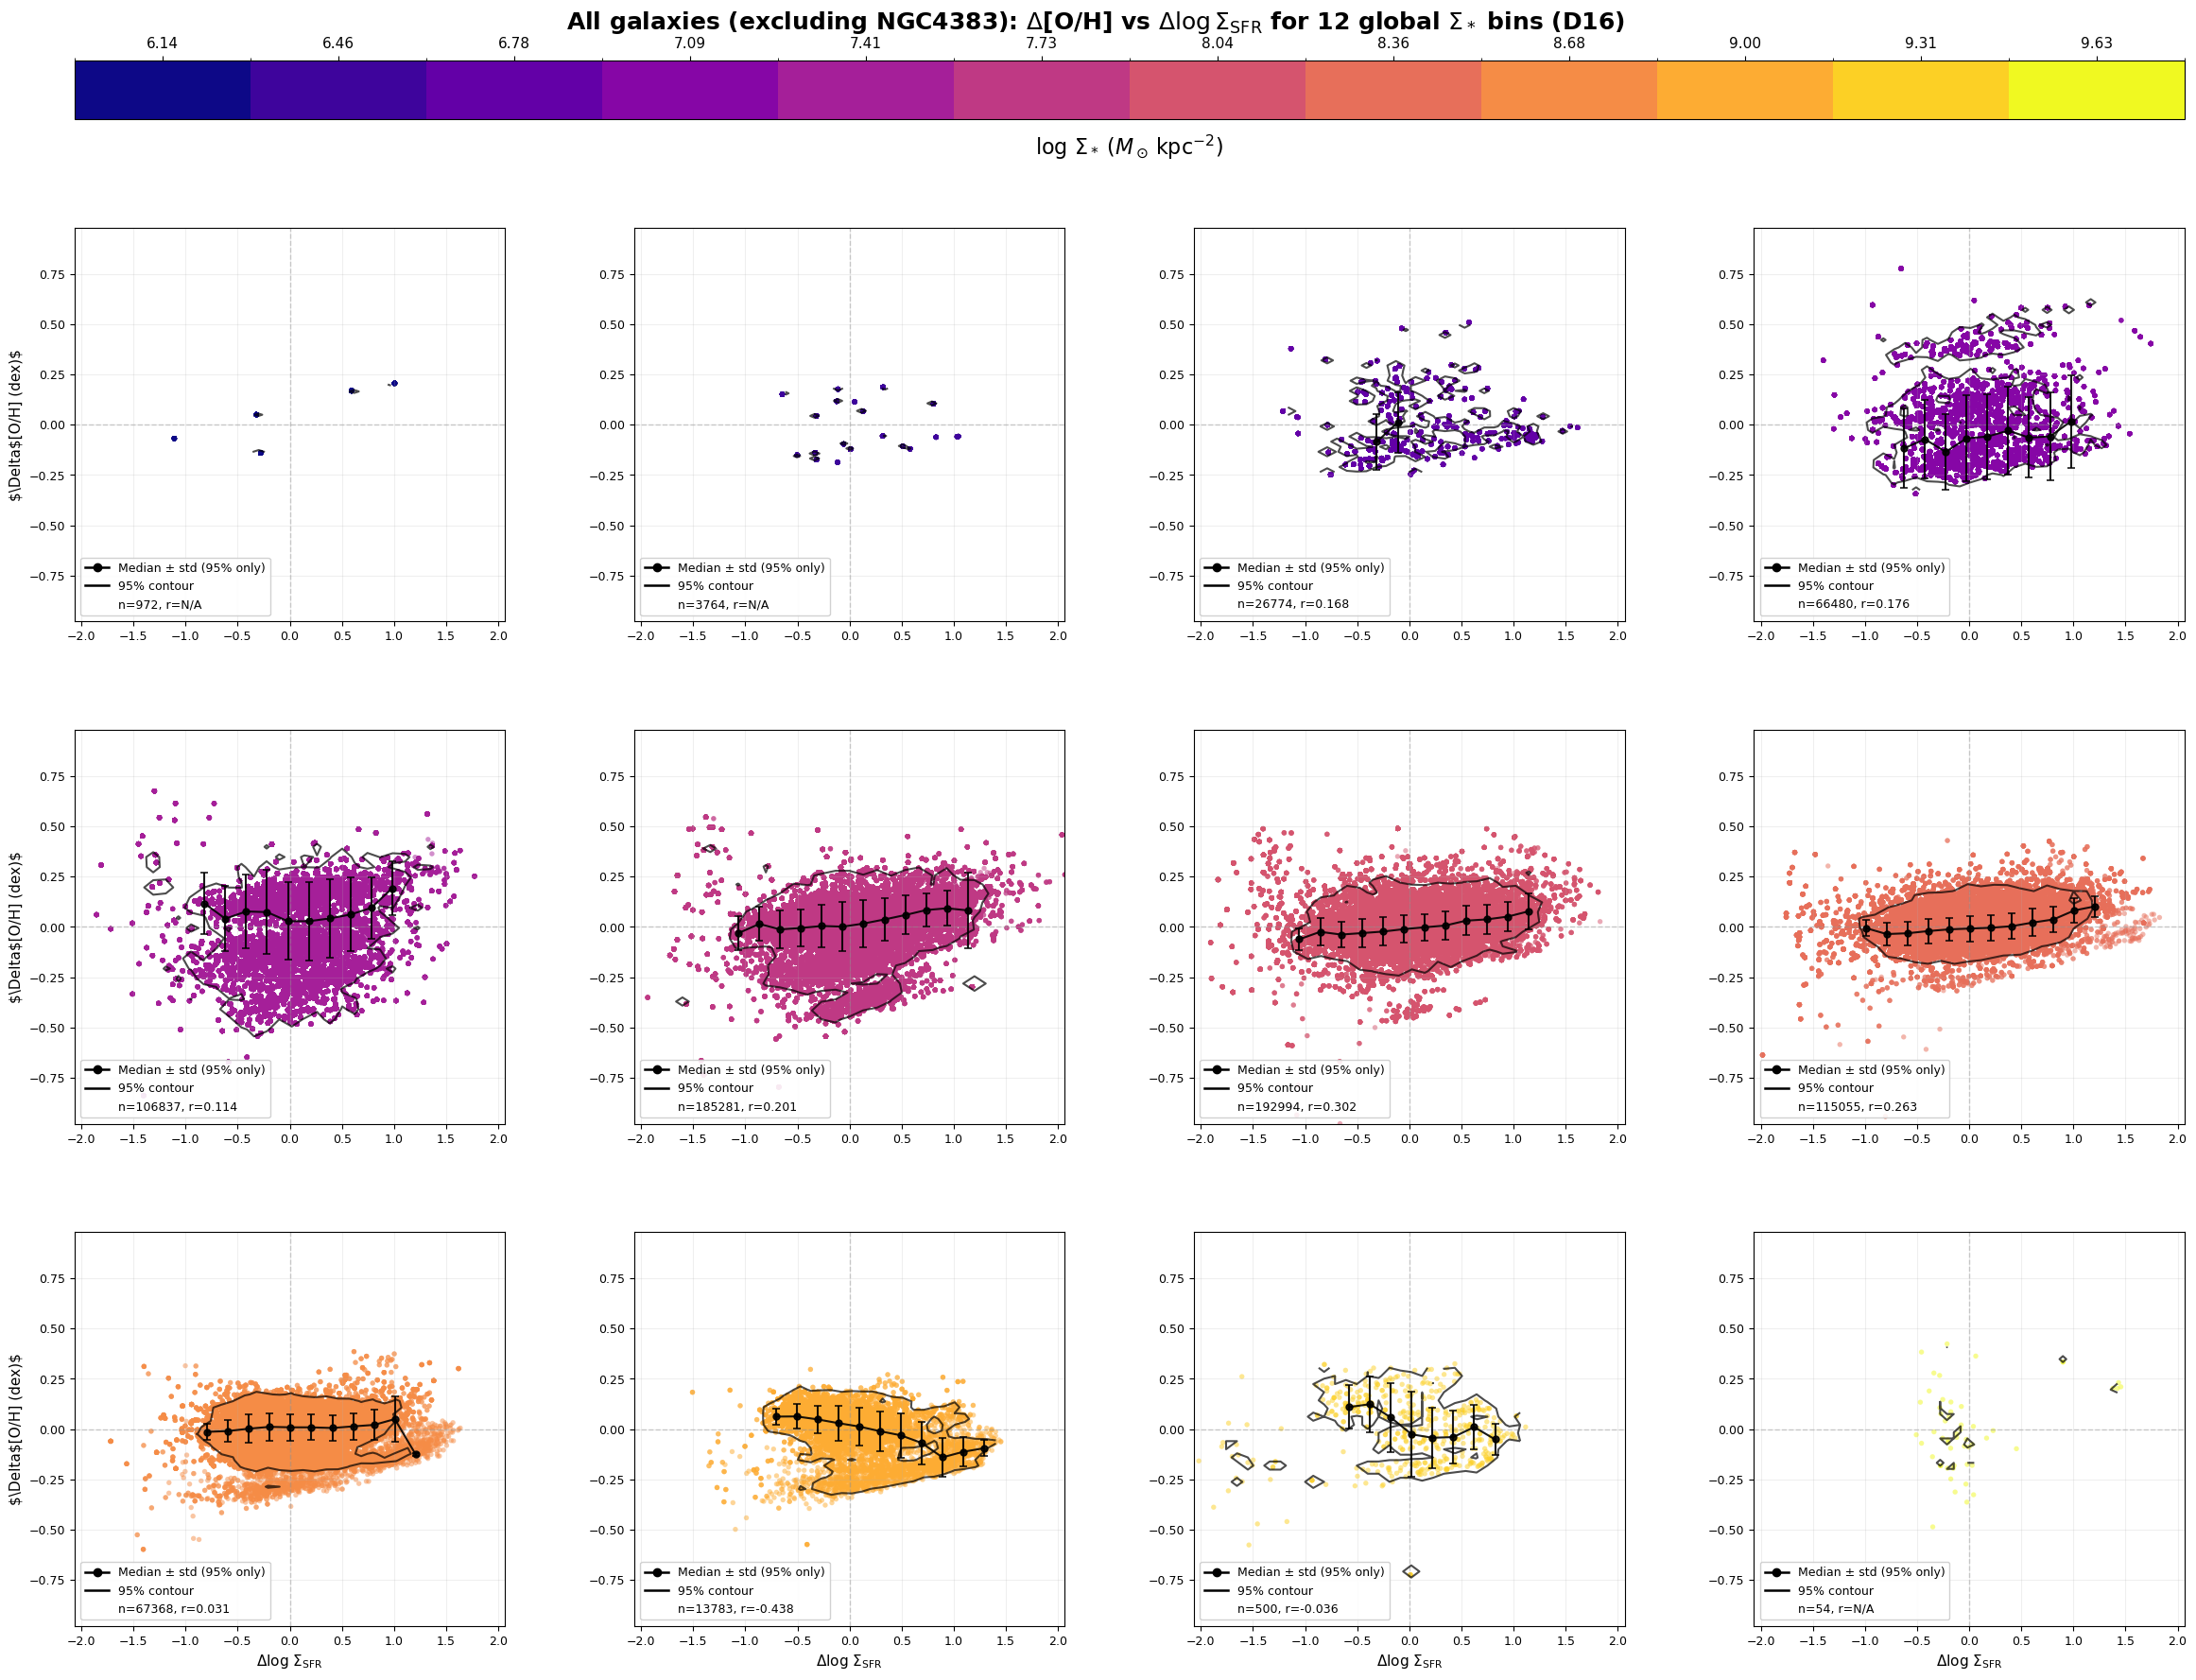

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using D16.


In [3]:
# ------------------------------------------------------------------
# Cell 3: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Pearson r uses same 95% contour + trend definition as Cell 2
# This cell uses the D16 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (D16)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_D16_HII' in h_gas:
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No D16 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 3: 12-panel offset relations for all galaxies (excluding NGC4383) using D16")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_d16_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_d16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_d16_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Pearson r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Pearson r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'r={pearson_r:.3f}'
                except Exception:
                    pearson_r, pearson_p = np.nan, np.nan
                    r_label = 'r=N/A'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (D16)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using D16.")

Cell 4: 12-panel offset relations for all galaxies (excluding NGC4383) using PG16
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


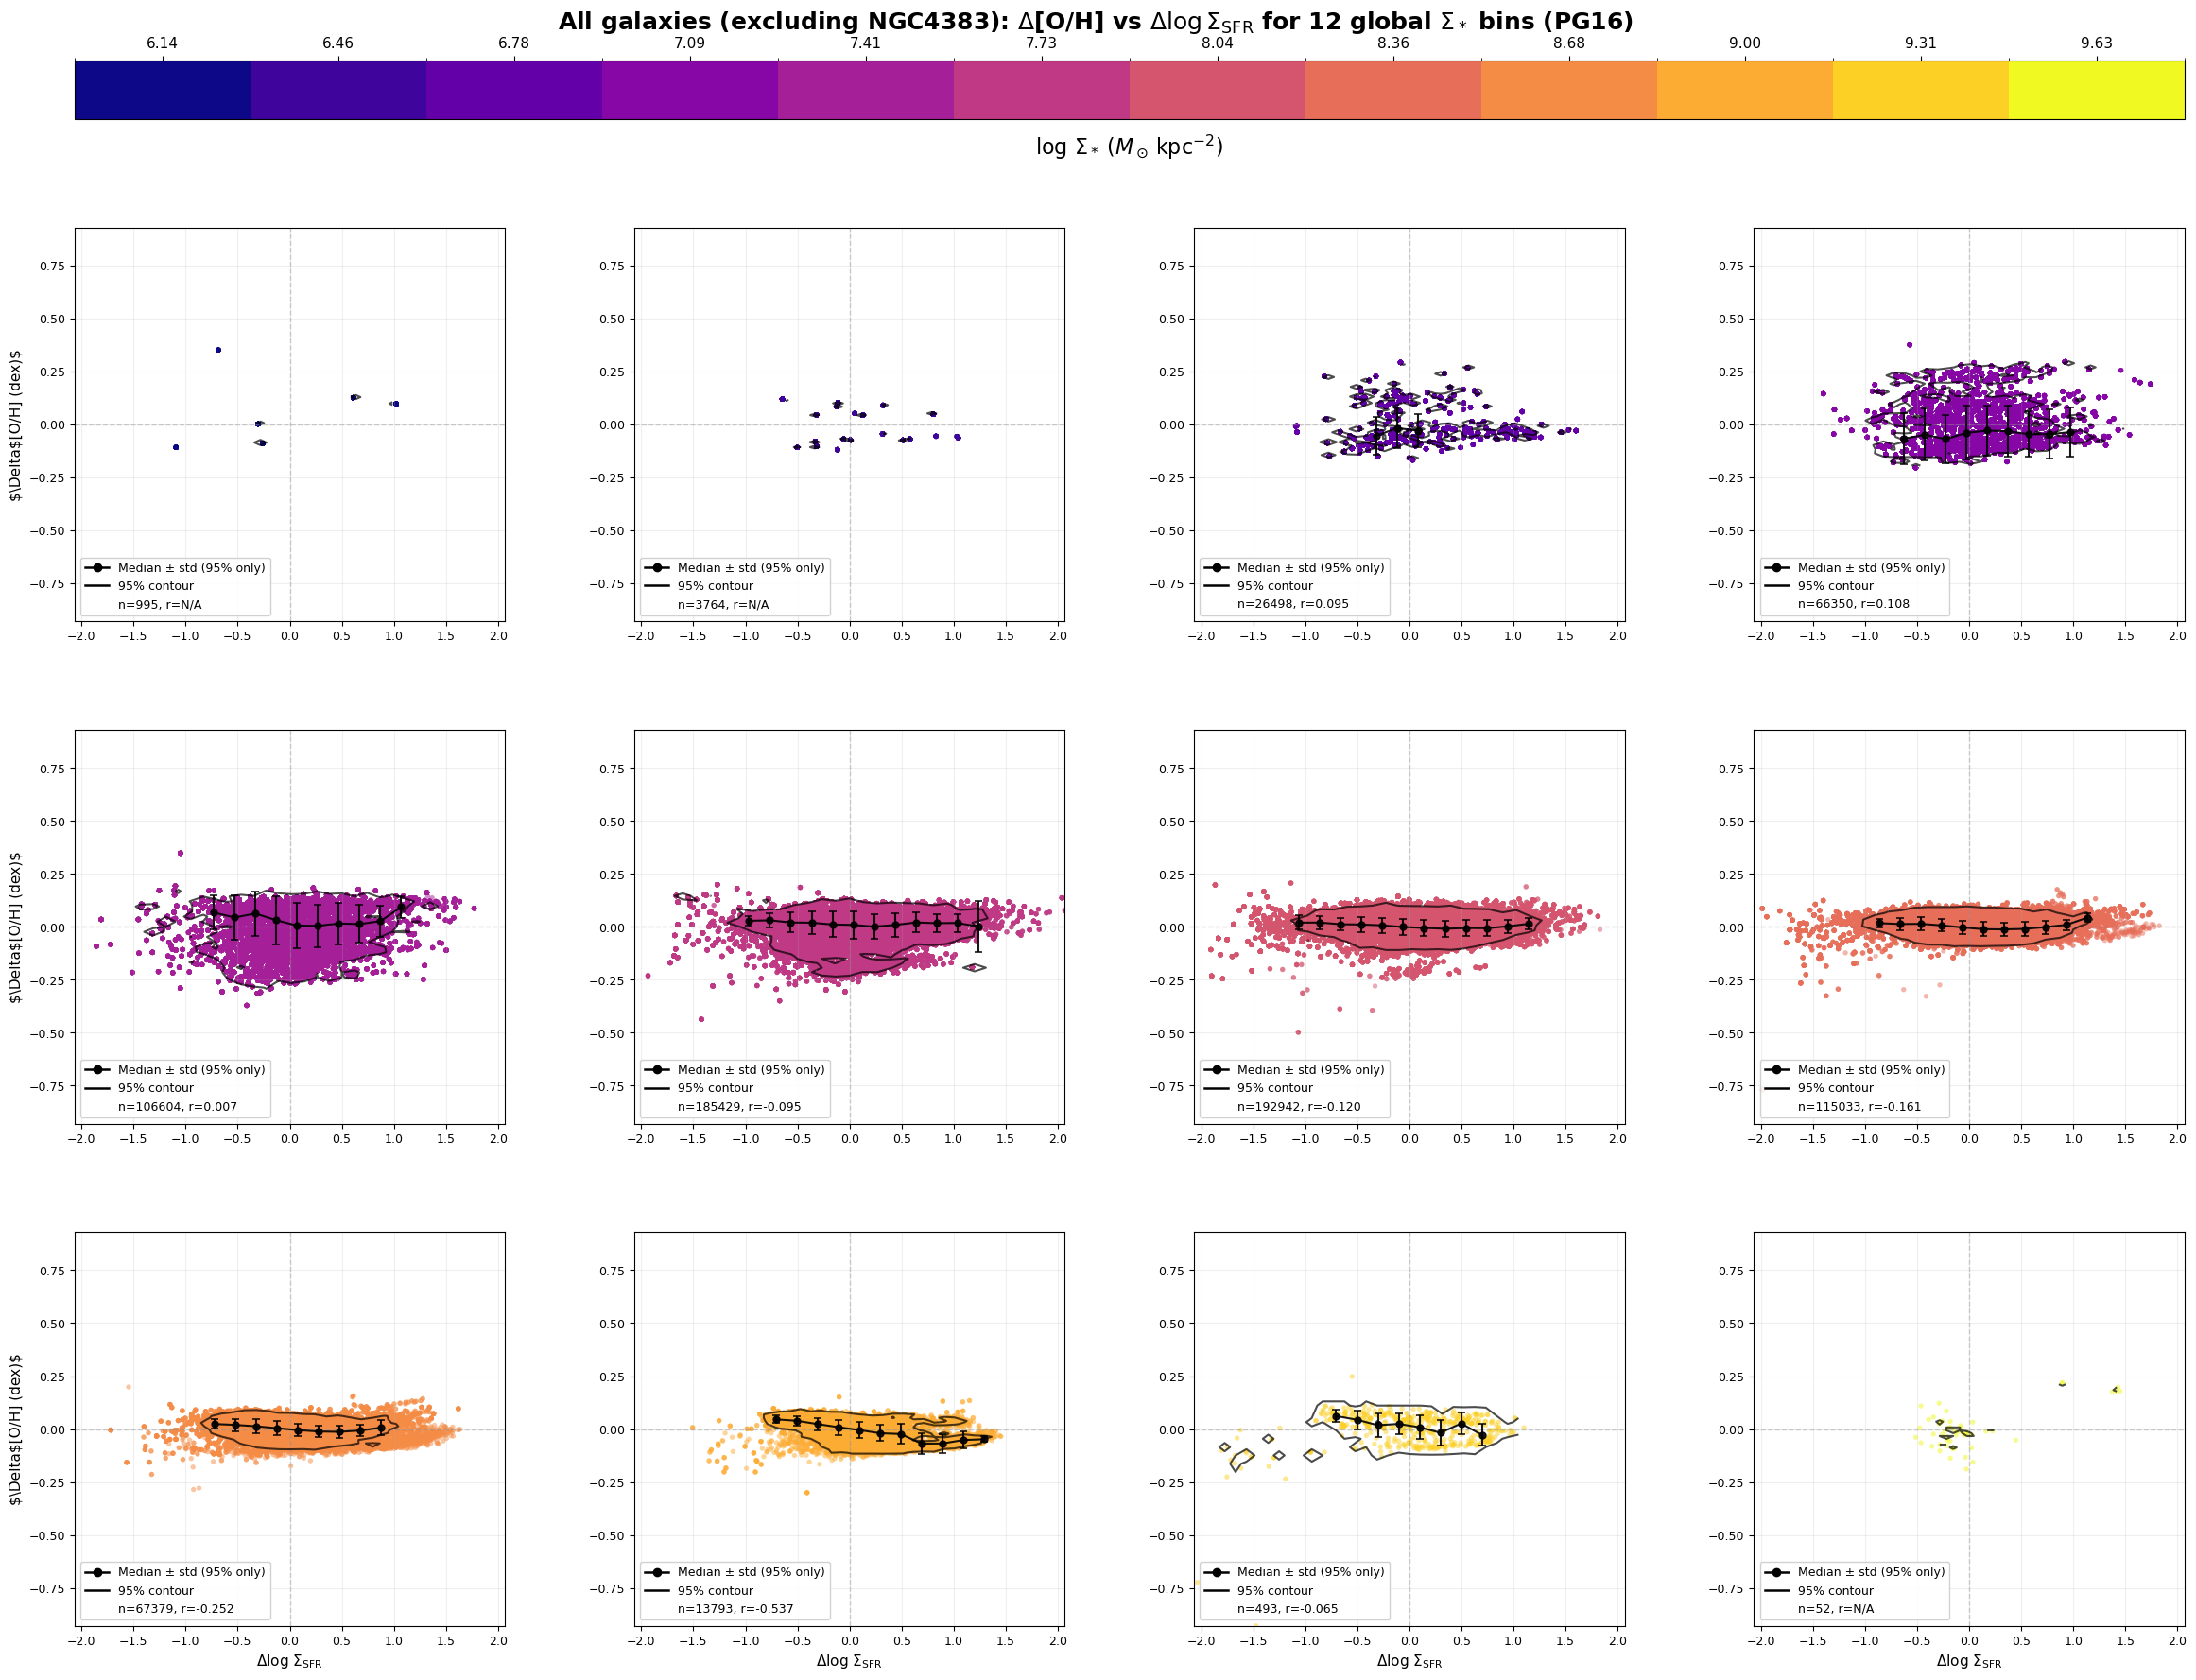

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using PG16.


In [4]:
# ------------------------------------------------------------------
# Cell 4: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Pearson r uses same 95% contour + trend definition as Cell 2
# This cell uses the PG16 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (PG16)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_PG16_HII' in h_gas:
            oh_map = h_gas['O_H_PG16_HII'].data
            indicator_name = 'PG16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No PG16 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 4: 12-panel offset relations for all galaxies (excluding NGC4383) using PG16")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_pg16_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_pg16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_pg16_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Pearson r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Pearson r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'r={pearson_r:.3f}'
                except Exception:
                    pearson_r, pearson_p = np.nan, np.nan
                    r_label = 'r=N/A'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (PG16)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using PG16.")


Cell 5: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-C20
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


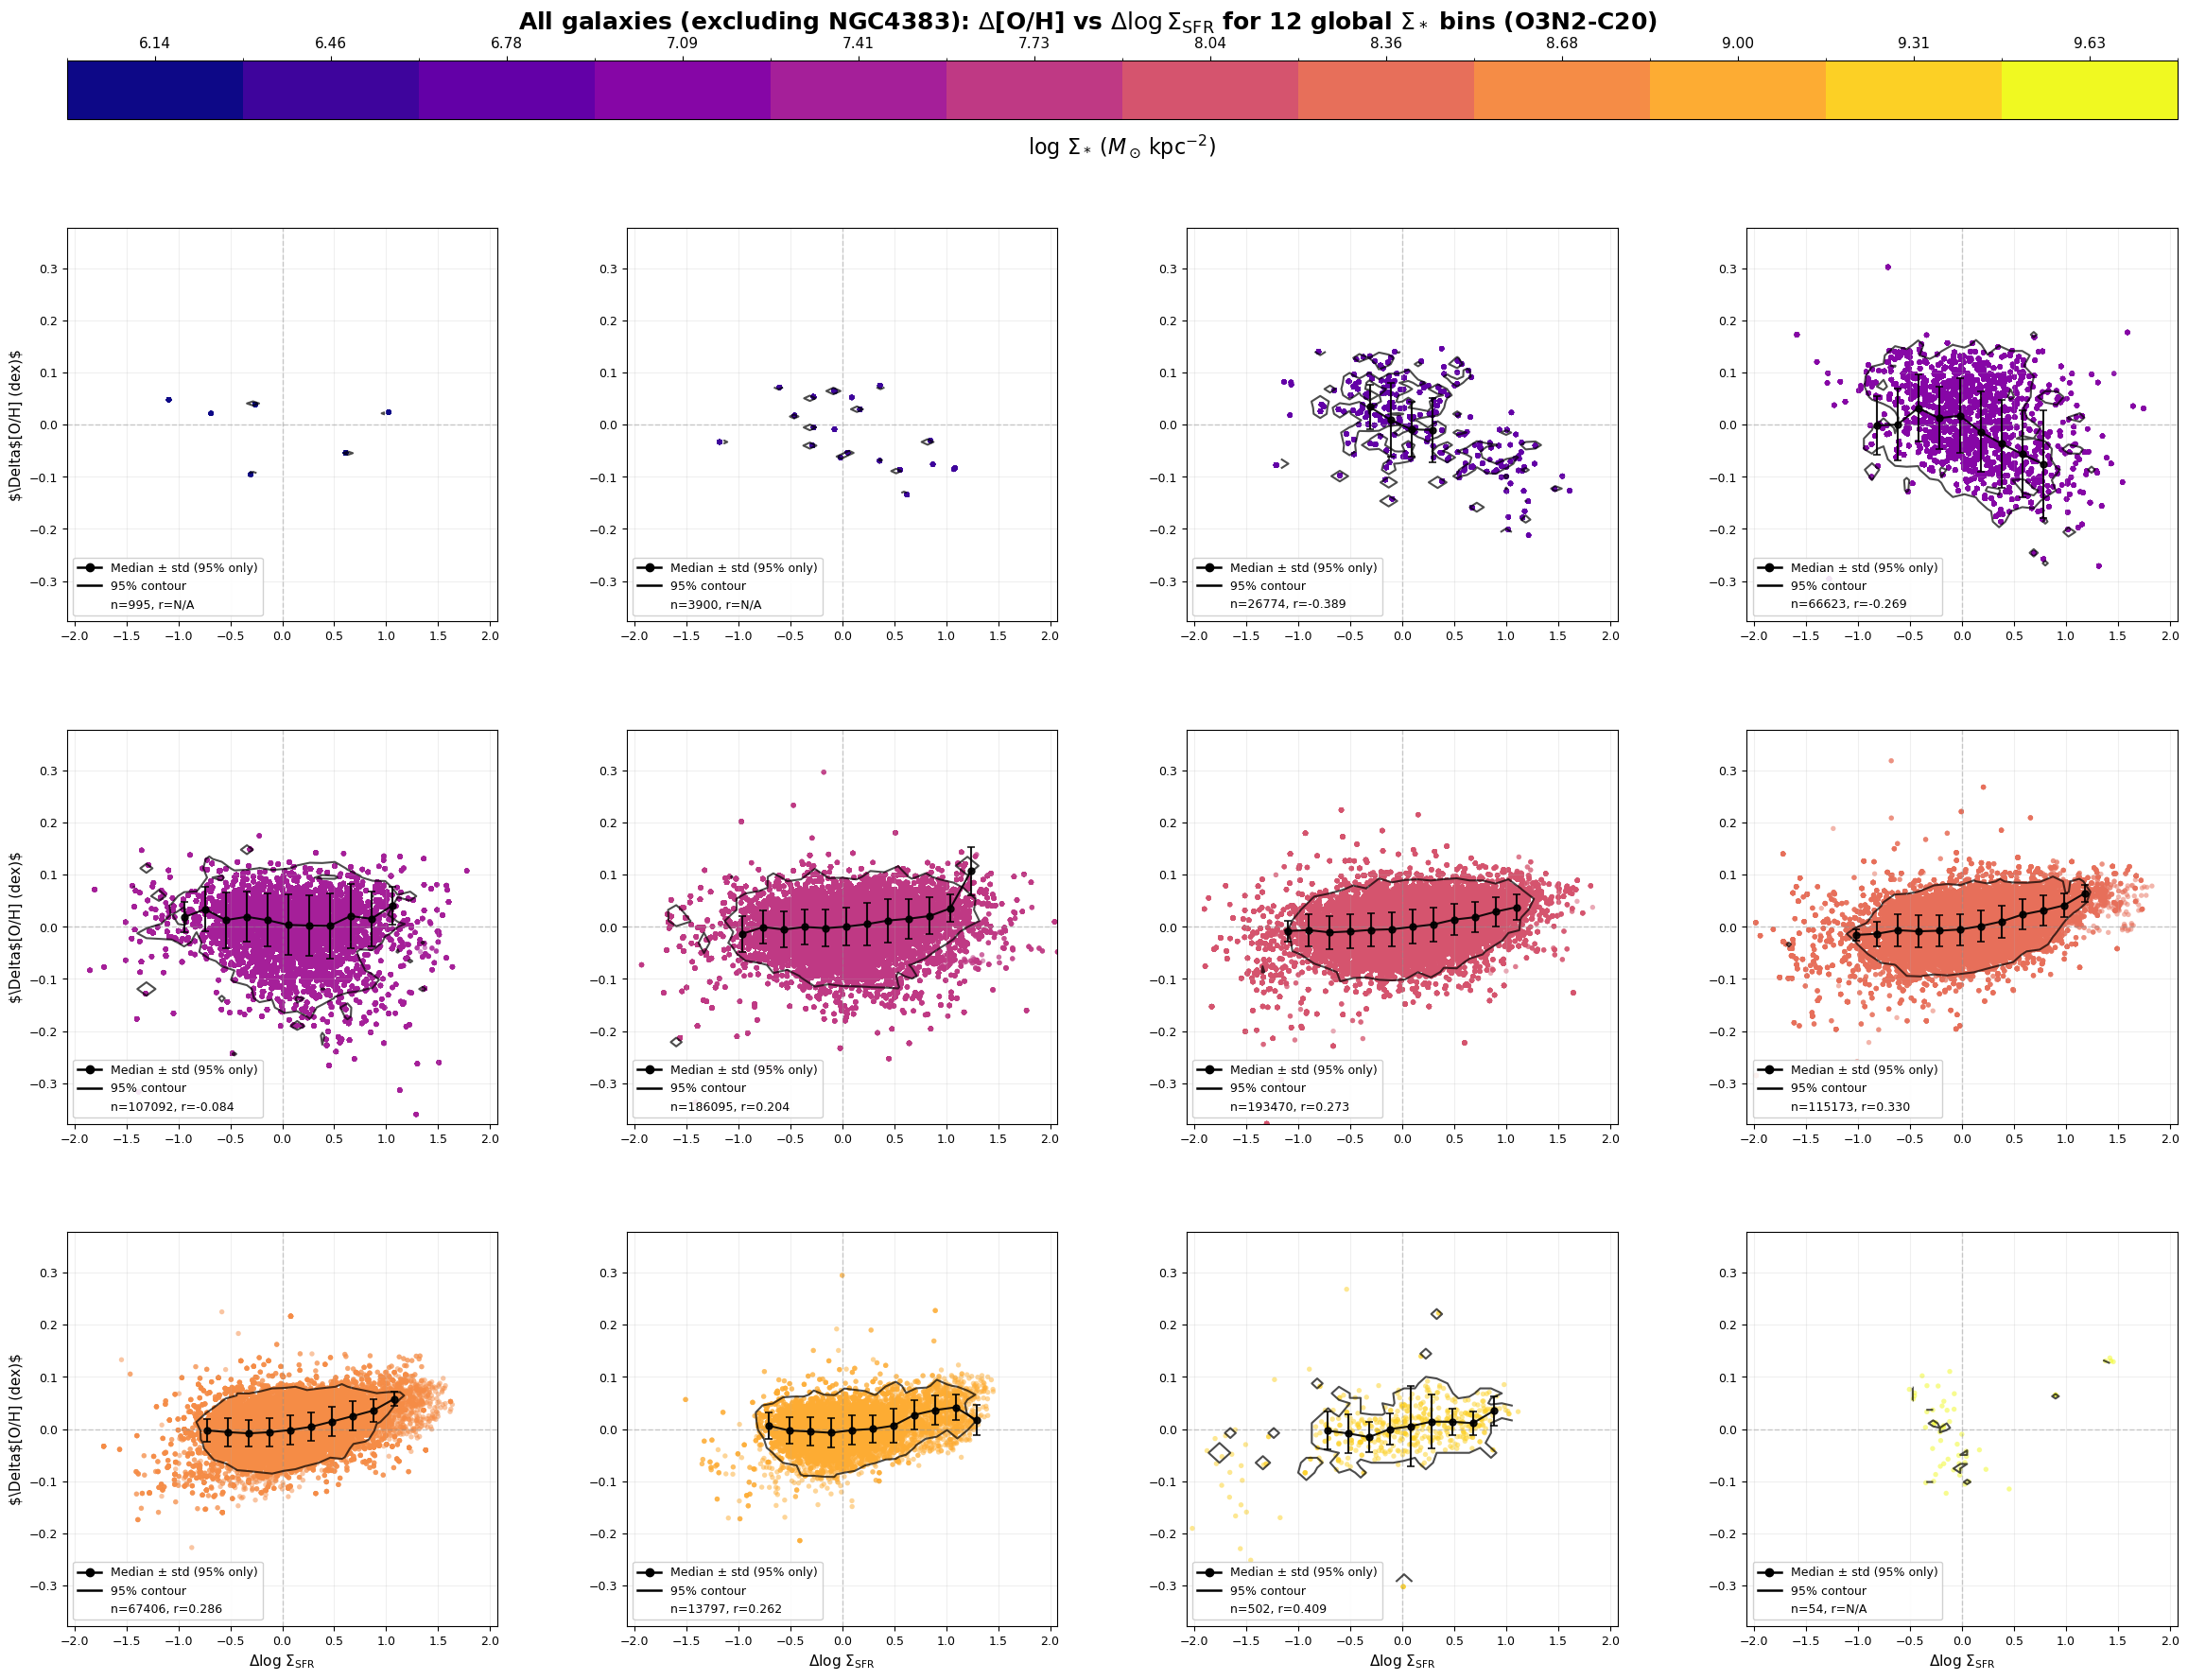

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-C20.


In [5]:
# ------------------------------------------------------------------
# Cell 5: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Pearson r uses same 95% contour + trend definition as Cell 2
# This cell uses the O3N2-C20 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-C20)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_O3N2_C20_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_C20_HII'].data
            indicator_name = 'O3N2-C20'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-C20 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 5: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-C20")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_o3n2_c20_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_c20_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_o3n2_c20_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Pearson r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Pearson r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'r={pearson_r:.3f}'
                except Exception:
                    pearson_r, pearson_p = np.nan, np.nan
                    r_label = 'r=N/A'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (O3N2-C20)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-C20.")


## 20251122 Try Spearman correlation instead of Pearson

12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-M13
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


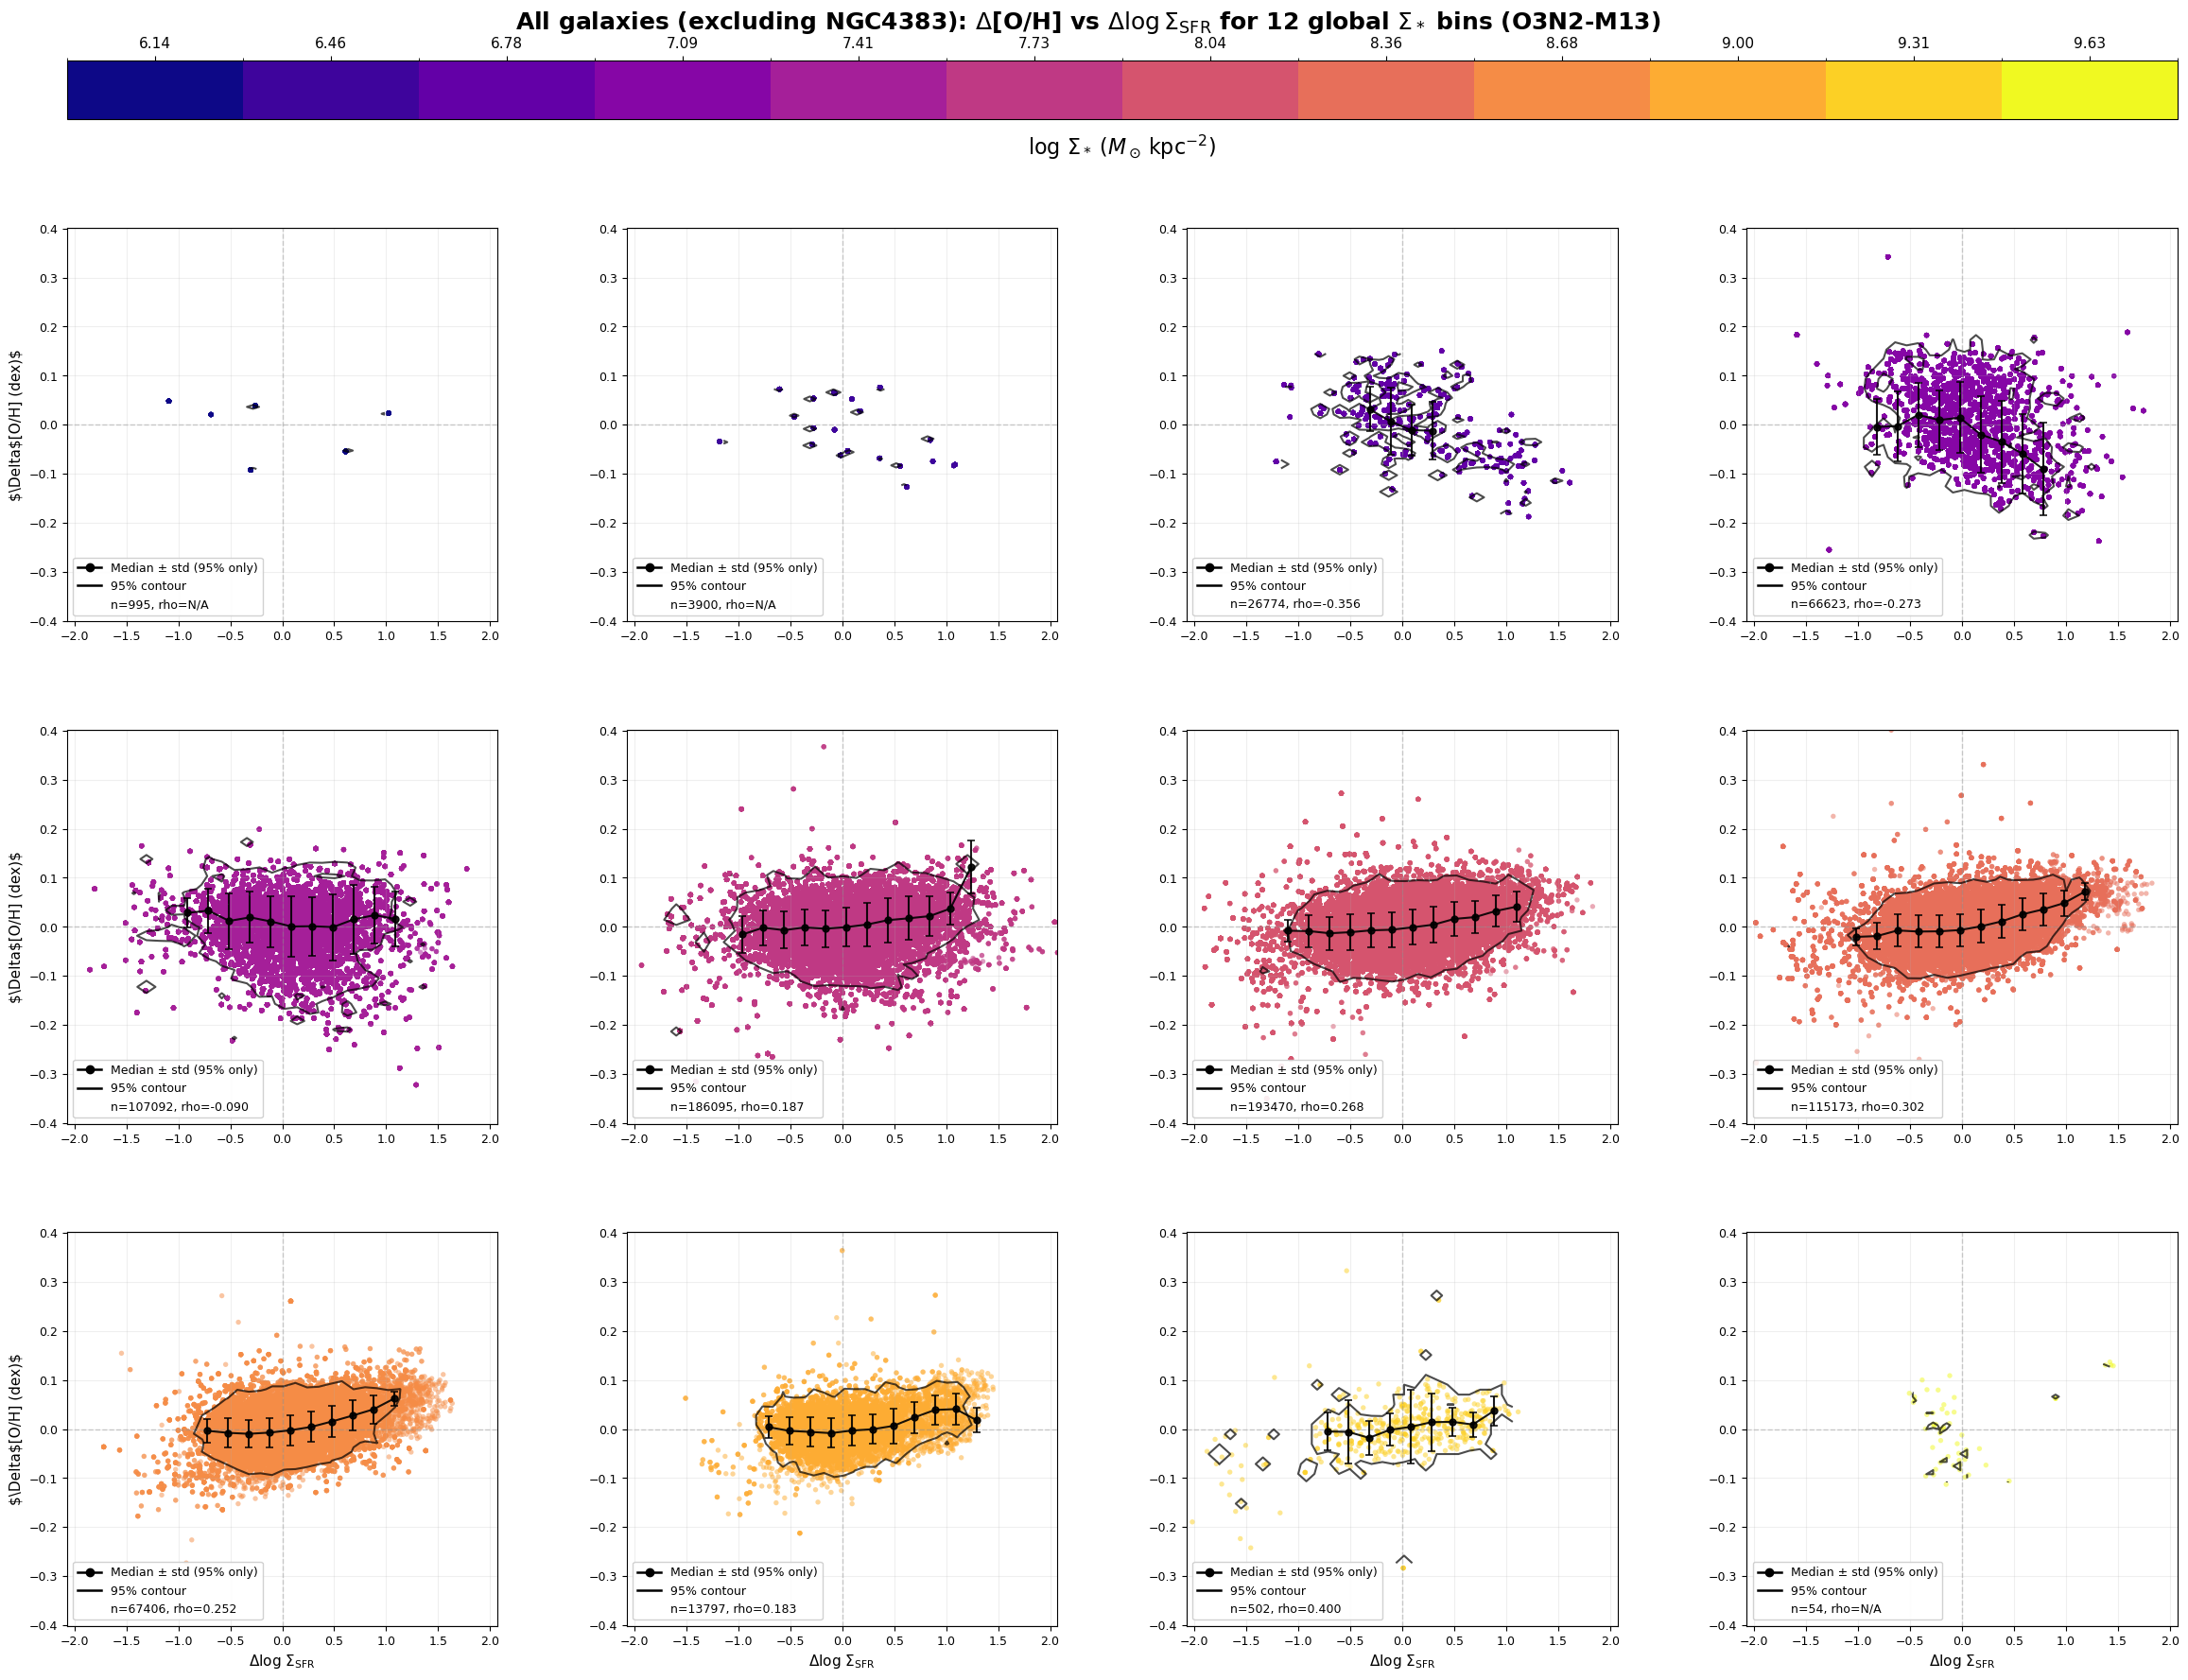

In [6]:
# ------------------------------------------------------------------
# Cell 3: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Spearman r uses same 95% contour + trend definition as Cell 2
# This cell uses the O3N2-M13 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-M13)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-M13 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-M13")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_o3n2_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Spearman r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Spearman r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    spearman_r, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'rho={spearman_r:.3f}'
                except Exception:
                    spearman_r, spearman_p = np.nan, np.nan
                    r_label = 'rho=N/A'
            else:
                spearman_r, spearman_p = np.nan, np.nan
                r_label = 'rho=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (O3N2-M13)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()

Cell 4: 12-panel offset relations for all galaxies (excluding NGC4383) using D16
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


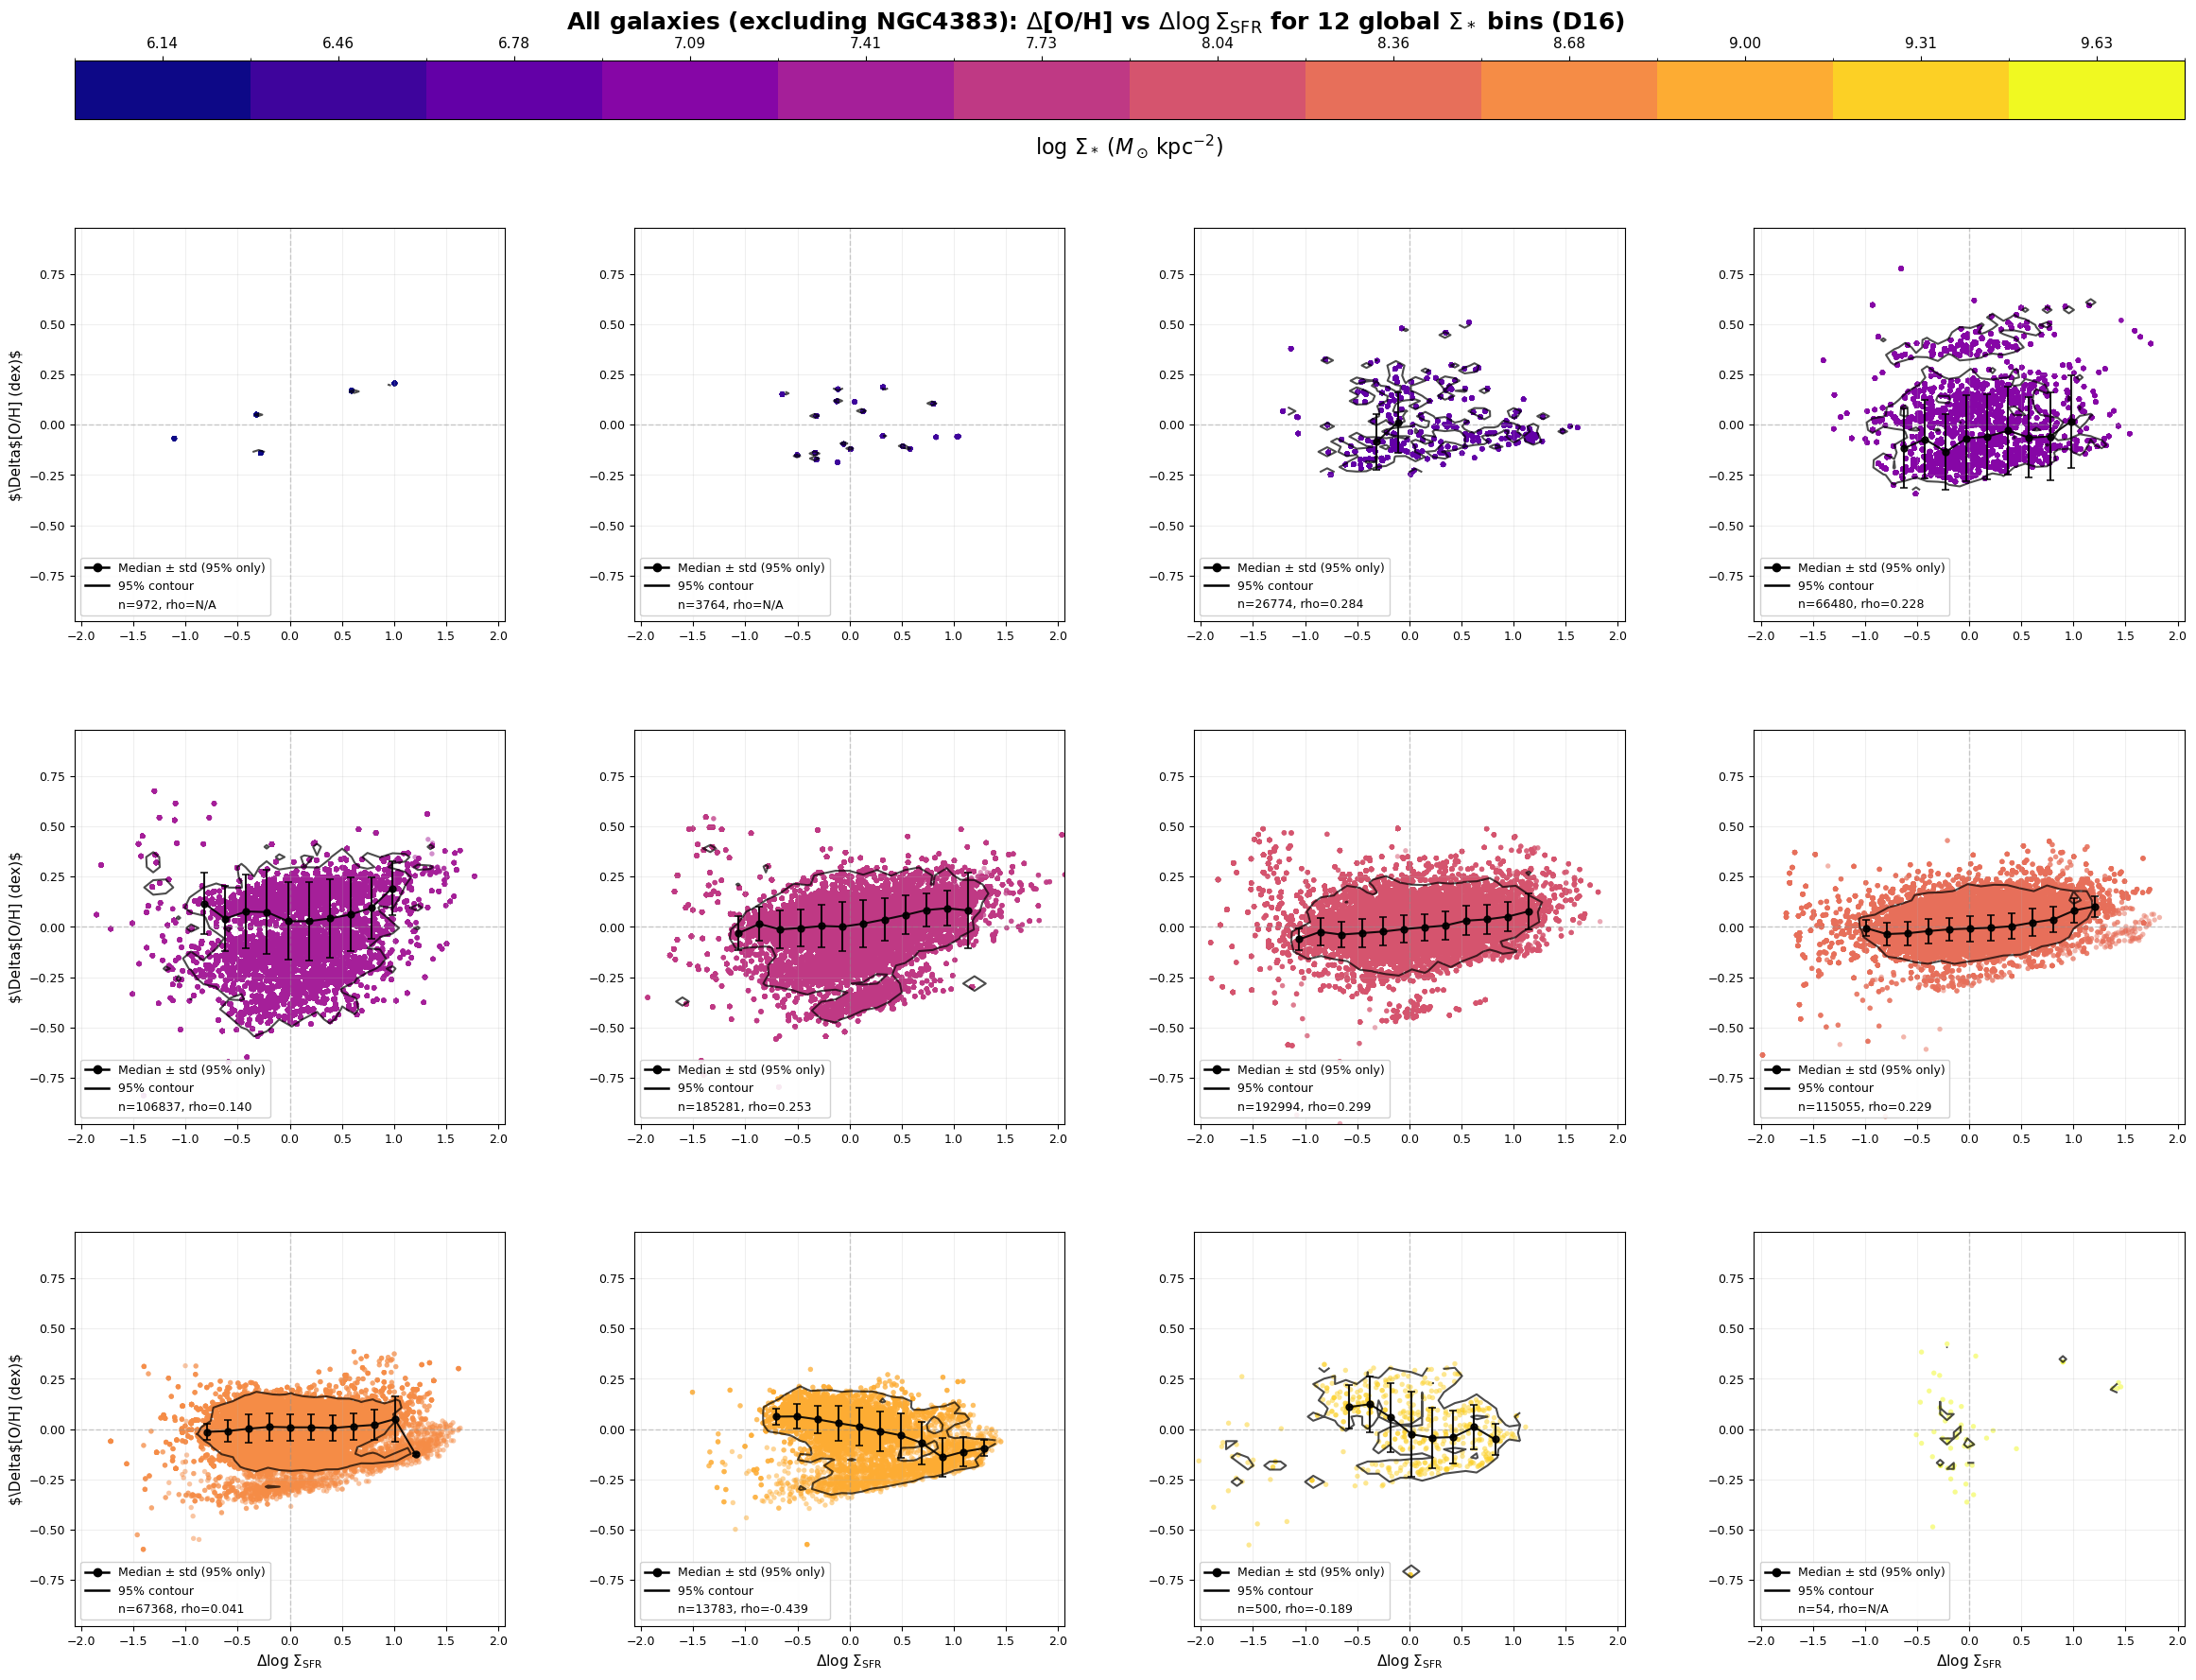

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using D16.


In [7]:
# ------------------------------------------------------------------
# Cell 4: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Spearman r uses same 95% contour + trend definition as Cell 2
# This cell uses the D16 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (D16)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_D16_HII' in h_gas:
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No D16 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 4: 12-panel offset relations for all galaxies (excluding NGC4383) using D16")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_d16_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_d16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_d16_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Spearman r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Spearman r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    spearman_r, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'rho={spearman_r:.3f}'
                except Exception:
                    spearman_r, spearman_p = np.nan, np.nan
                    r_label = 'rho=N/A'
            else:
                spearman_r, spearman_p = np.nan, np.nan
                r_label = 'rho=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (D16)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using D16.")

Cell 5: 12-panel offset relations for all galaxies (excluding NGC4383) using PG16
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


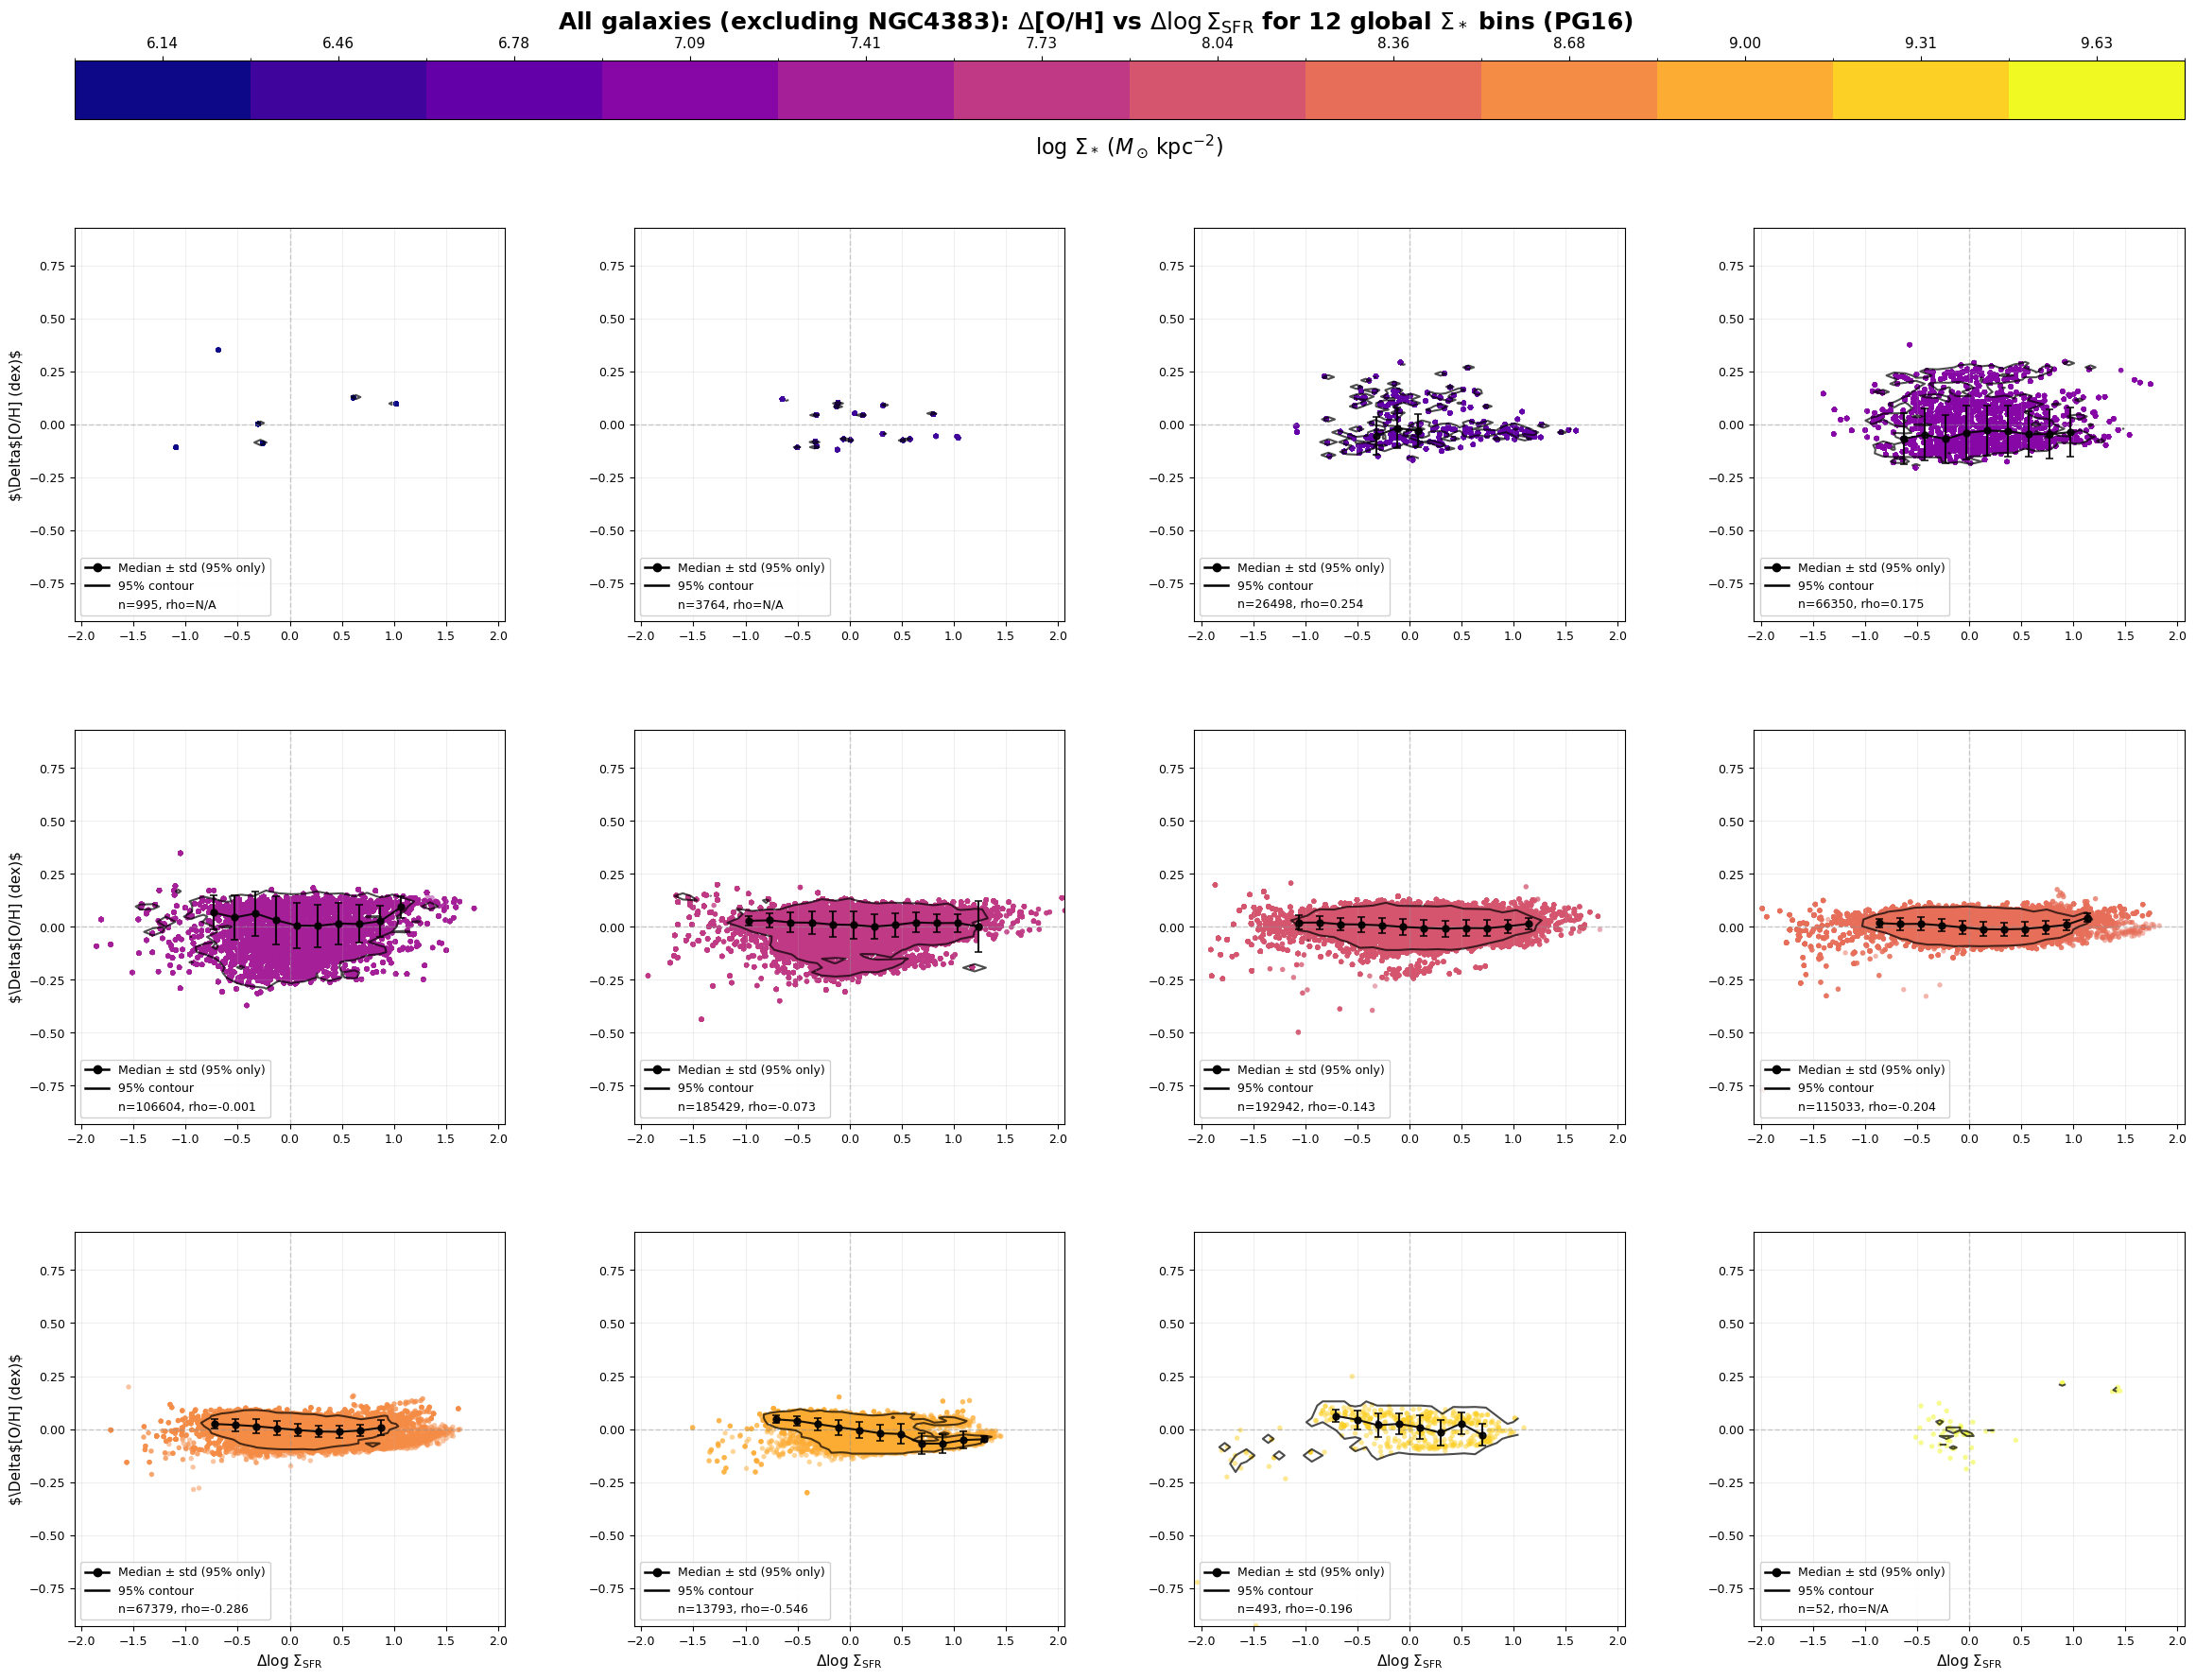

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using PG16.


In [8]:
# ------------------------------------------------------------------
# Cell 5: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Spearman r uses same 95% contour + trend definition as Cell 2
# This cell uses the PG16 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (PG16)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_PG16_HII' in h_gas:
            oh_map = h_gas['O_H_PG16_HII'].data
            indicator_name = 'PG16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No PG16 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 5: 12-panel offset relations for all galaxies (excluding NGC4383) using PG16")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_pg16_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_pg16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_pg16_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Spearman r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Spearman r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    spearman_r, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'rho={spearman_r:.3f}'
                except Exception:
                    spearman_r, spearman_p = np.nan, np.nan
                    r_label = 'rho=N/A'
            else:
                spearman_r, spearman_p = np.nan, np.nan
                r_label = 'rho=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (PG16)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using PG16.")

Cell 6: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-C20
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Used galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


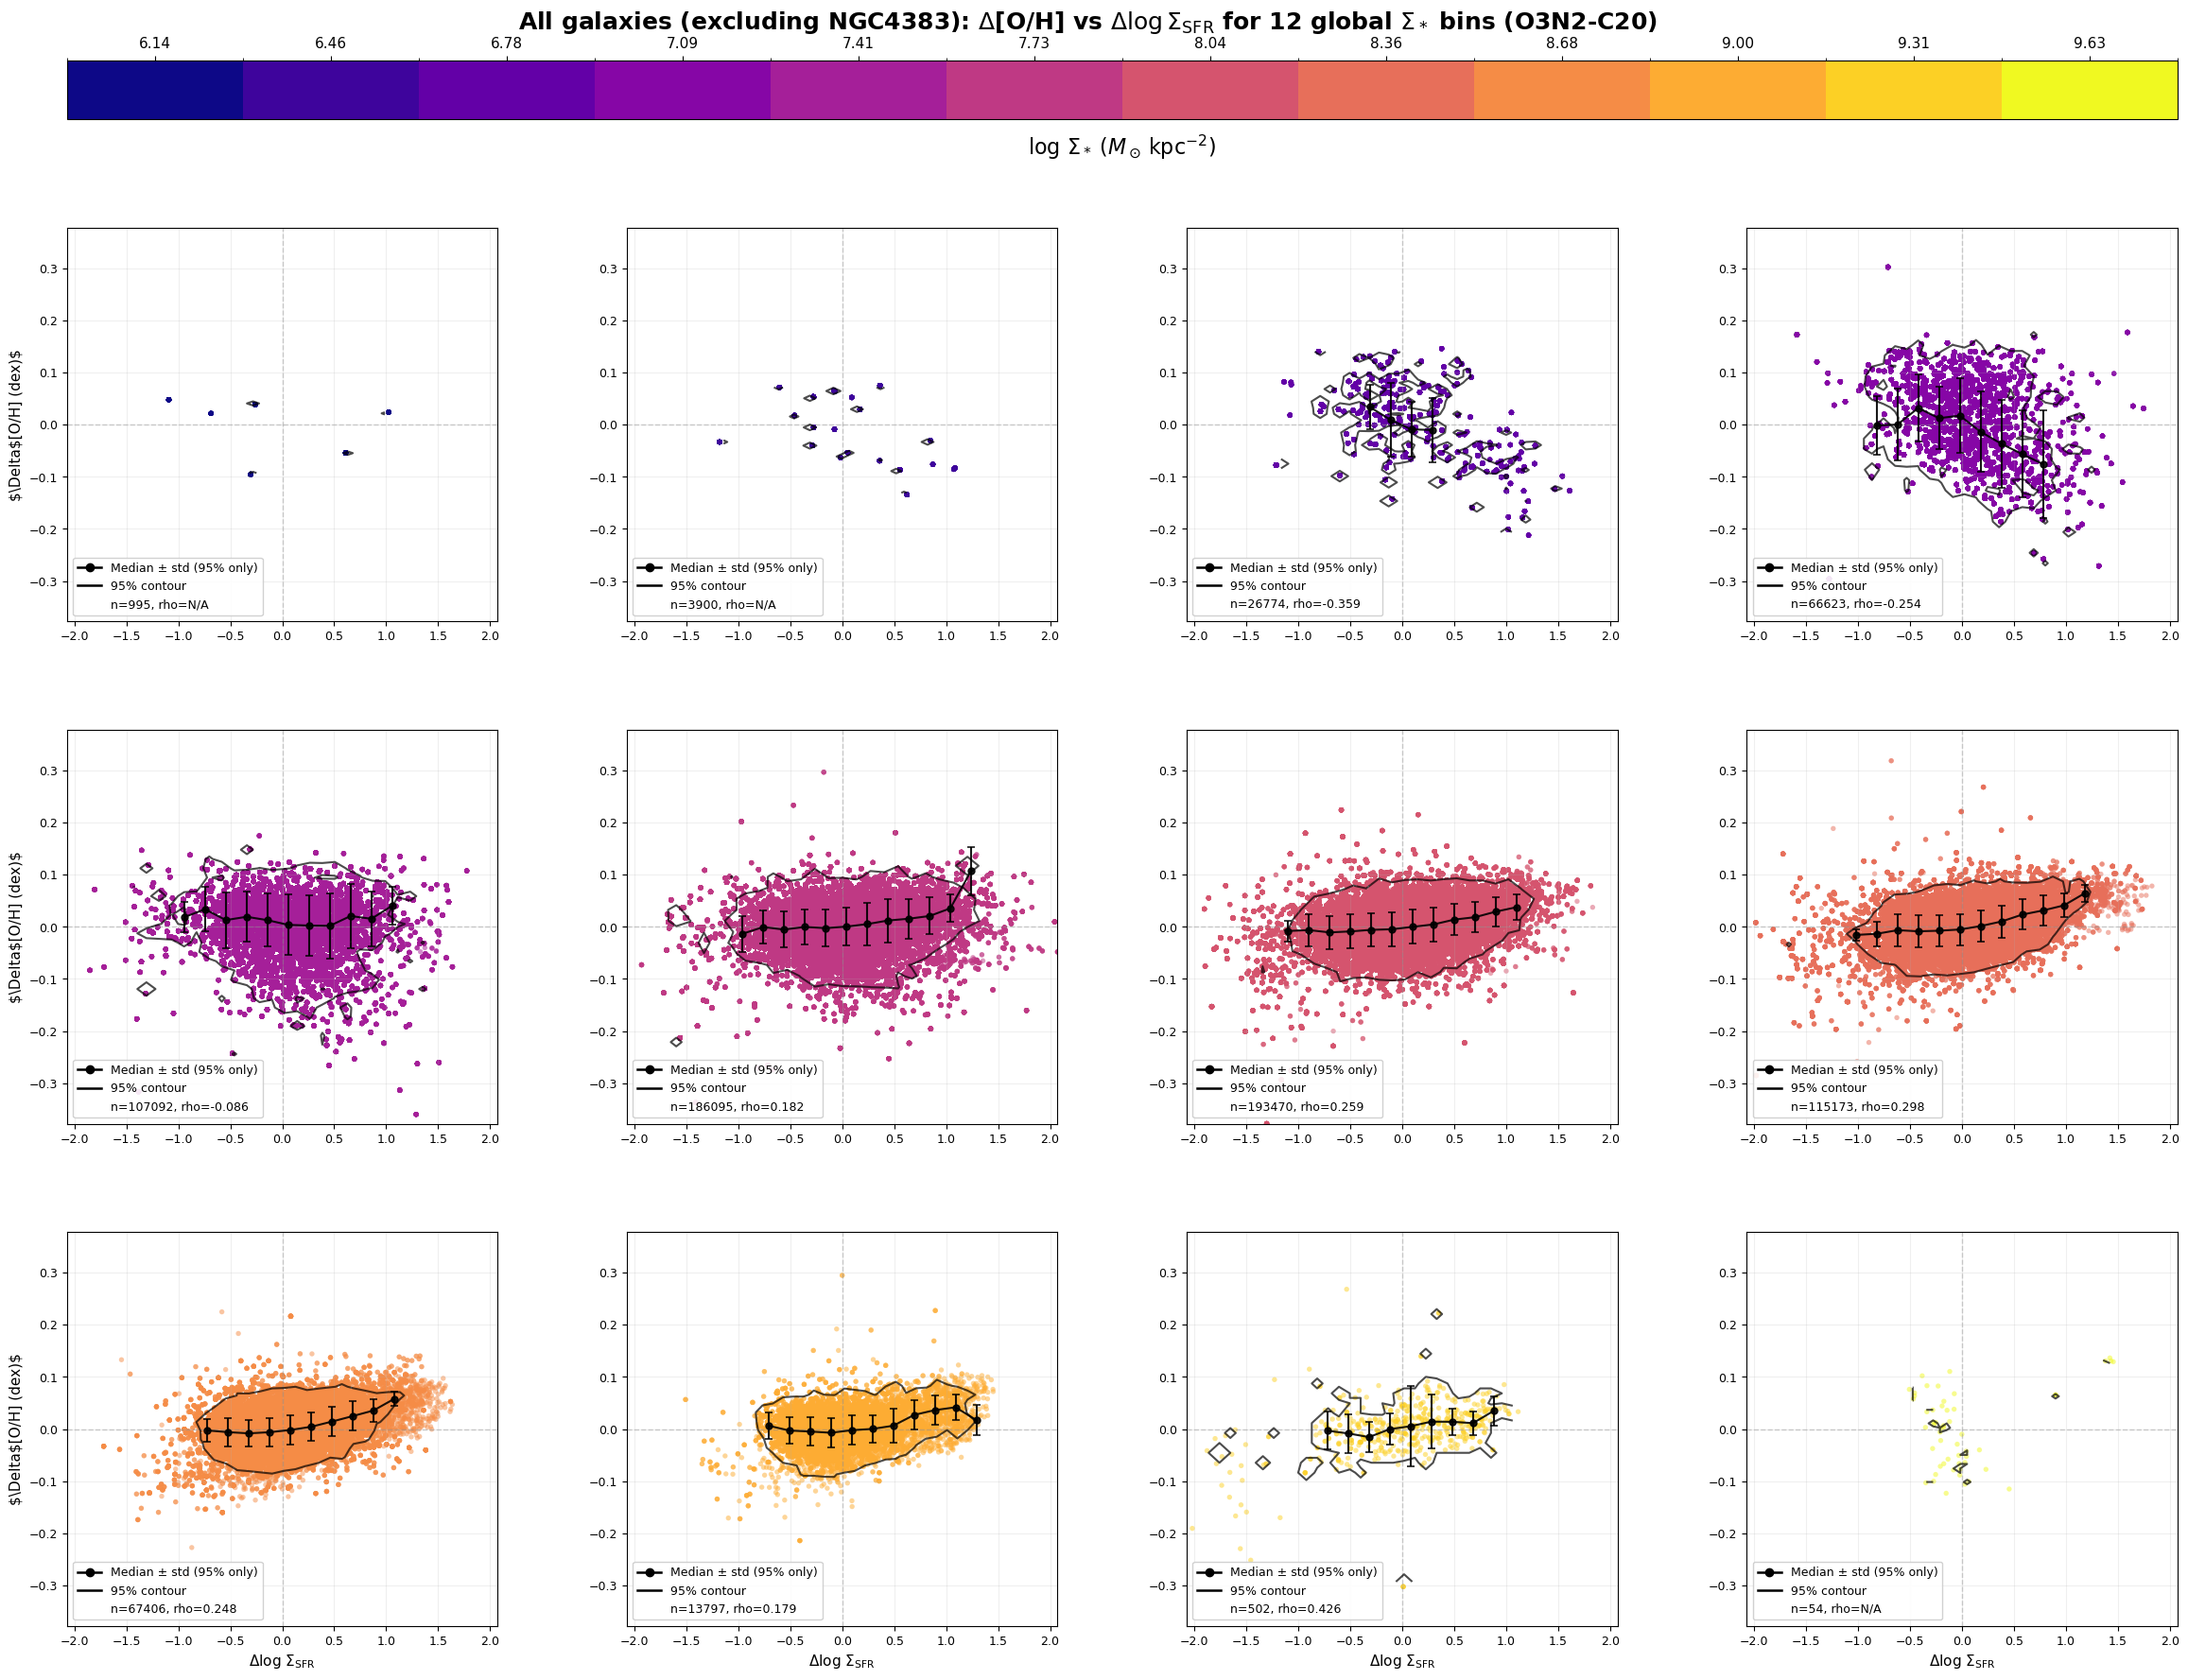

12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-C20.


In [9]:
# ------------------------------------------------------------------
# Cell 6: 12-panel offset relations for ALL galaxies (excluding NGC4383)
# Each panel is one Σ_* bin; points from all galaxies in that bin
# Spearman r uses same 95% contour + trend definition as Cell 2
# This cell uses the O3N2-C20 metallicity indicator only.
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-C20)
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        if 'O_H_O3N2_C20_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_C20_HII'].data
            indicator_name = 'O3N2-C20'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-C20 metallicity extension found for {gal}. Available: {available}")
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Build combined sample of all galaxies and define global Σ_* bins
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print("Cell 6: 12-panel offset relations for all galaxies (excluding NGC4383) using O3N2-C20")
print("All galaxies:", ", ".join(galaxies_all))
print("Used galaxies:", ", ".join(galaxies))
print("=" * 80)

# Load all galaxies, stack valid spaxels
sigM_all = []
sigSFR_all = []
oh_all = []

for gal in galaxies:
    try:
        sigM, sigSFR, oh_o3n2_c20_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_c20_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        continue

    sigM_all.append(sigM[valid_all].ravel())
    sigSFR_all.append(sigSFR[valid_all].ravel())
    oh_all.append(oh_o3n2_c20_map[valid_all].ravel())

if not sigM_all:
    print("No valid data across galaxies; nothing to plot.")
else:
    sigM_all = np.concatenate(sigM_all)
    sigSFR_all = np.concatenate(sigSFR_all)
    oh_all = np.concatenate(oh_all)

    # Define 12 global Σ_* bins over the combined sample
    n_bins = 12
    sigmaM_min = np.nanmin(sigM_all)
    sigmaM_max = np.nanmax(sigM_all)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Use discrete colormap in Σ_*
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Global symmetric axis limits using combined sample
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    # ------------------------------------------------------------------
    # Create 3x4 grid of panels + top colorbar
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(4, 4, figure=fig,
                           height_ratios=[0.15, 1, 1, 1],
                           hspace=0.35, wspace=0.3,
                           top=0.96, bottom=0.04, left=0.05, right=0.98)

    cbar_ax = fig.add_subplot(gs[0, :])
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)

    # ------------------------------------------------------------------
    # For each global Σ_* bin, plot offsets from ALL galaxies
    # and compute Spearman r with same 95% contour + trend rule
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]

        if i == 0:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all <= sigmaM_bin_edges[i+1])
        else:
            bin_mask = (sigM_all >= sigmaM_bin_edges[i]) & (sigM_all < sigmaM_bin_edges[i+1])

        n_pixels = np.sum(bin_mask)

        if n_pixels > 0:
            sfr_bin = sigSFR_all[bin_mask]
            oh_bin = oh_all[bin_mask]

            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))

            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr],
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)

            # 95% contour using combined sample for this bin
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True

            # Median trend inside 95% contour (same function/thresholds)
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size >= 2
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)

            # Spearman r only if trend exists and >2 valid inside contour
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                try:
                    spearman_r, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                    oh_offset[contour_mask & valid_corr])
                    r_label = f'rho={spearman_r:.3f}'
                except Exception:
                    spearman_r, spearman_p = np.nan, np.nan
                    r_label = 'rho=N/A'
            else:
                spearman_r, spearman_p = np.nan, np.nan
                r_label = 'rho=N/A'

            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)

            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            ax.grid(True, alpha=0.2)

            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)

            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)$', fontsize=11)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)

            ax.tick_params(labelsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar along top
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.suptitle(r'All galaxies (excluding NGC4383): $\Delta$[O/H] vs $\Delta \log \Sigma_{\mathrm{SFR}}$ for 12 global $\Sigma_*$ bins (O3N2-C20)',
                 fontsize=18, y=0.99, fontweight='bold')
    plt.show()
    
    print("12-panel offset relation grid complete for all galaxies (excluding NGC4383) using O3N2-C20.")

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...


  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] axis limits: ±0.259
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, rho=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, rho=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, rho=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, rho=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, rho=0.340
    Bin 06 (8.22): n=4888, rho=0.310
    Bin 07 (8.39): n=2989, rho=0.209
    Bin 08 (8.55): n=1266, rho=0.265
    Bin 09 (8.72): n=750, rho=0.169
    Bin 10 (8.88): n=306, rho=0.234
    Bin 11 (9.05): n=131, rho=-0.064
    Bin 12 (9.21): n=33, rho=N/A (no trend or too few in 95%)

Processing NGC4064 ...
  Σ* range: 7.005 to 9.351
  Global Δlog(Σ_SFR) axis limits: ±2.265
  Global Δ[O/H] axis limits: ±0.281
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.10): n=254, rho=N/A (no trend or too few in 95%)
  

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_16576/4060830497.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


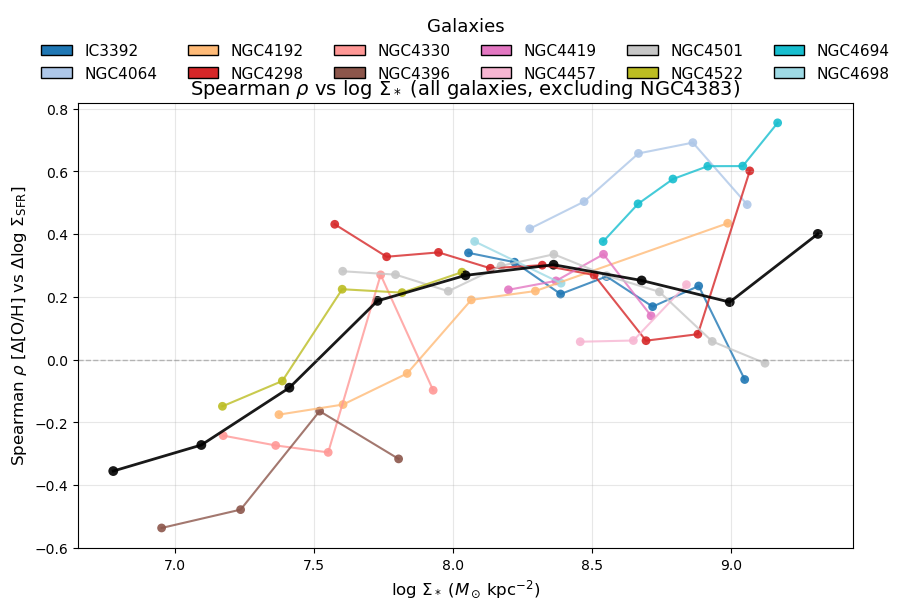

In [10]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, rho=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho={spearman_rho:.3f}")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (no trend or too few in 95%)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, rho=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho={rho_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

Offset relations and Spearman rho vs Σ_* (D16; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (D16) axis limits: ±0.257
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, rho=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, rho=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, rho=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, rho=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, rho=-0.131
    Bin 06 (8.22): n=4888, rho=-0.221
    Bin 07 (8.39): n=2989, rho=0.005
    Bin 08 (8.55): n=1266, rho=-0.059
    Bin 09 (8.72): 

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_16576/2677747860.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


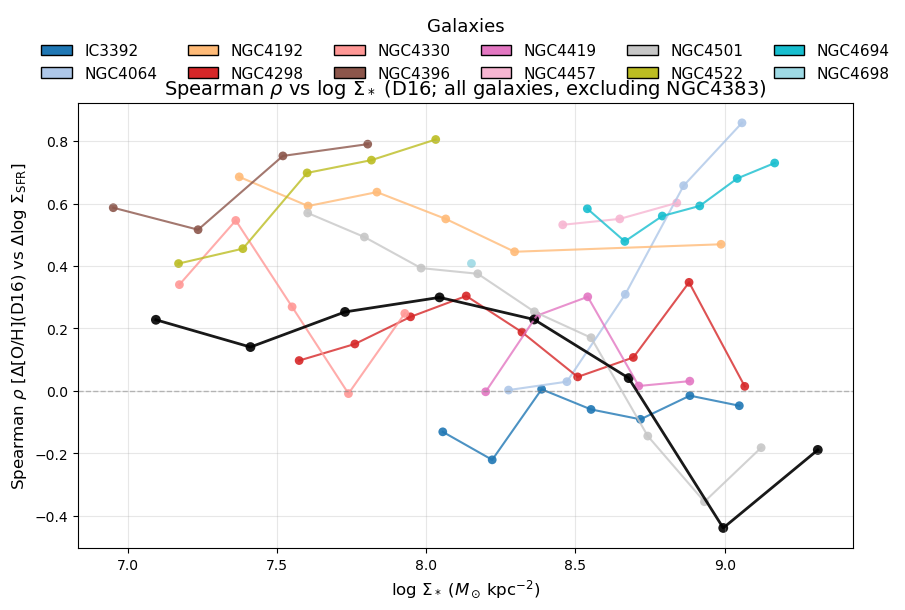

In [11]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (D16) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (D16 metallicity)
# ------------------------------------------------------------------
def load_maps_d16(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_D16_HII' in h_gas:
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No D16 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (D16; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_d16_map, indicator_name = load_maps_d16(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_d16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_d16_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_d16_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (D16) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, rho=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_d16_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho={spearman_rho:.3f}")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (no trend or too few in 95%)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy, D16):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method, D16)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together, D16)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, rho=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho={rho_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (D16)
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H](D16) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (D16; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Spearman rho values to plot (D16).")

Offset relations and Spearman rho vs Σ_* (PG16; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (PG16) axis limits: ±0.115
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, rho=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, rho=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, rho=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, rho=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, rho=-0.467
    Bin 06 (8.22): n=4888, rho=-0.484
    Bin 07 (8.39): n=2989, rho=-0.252
    Bin 08 (8.55): n=1266, rho=-0.288
    Bin 09 (8.72

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_16576/250870267.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


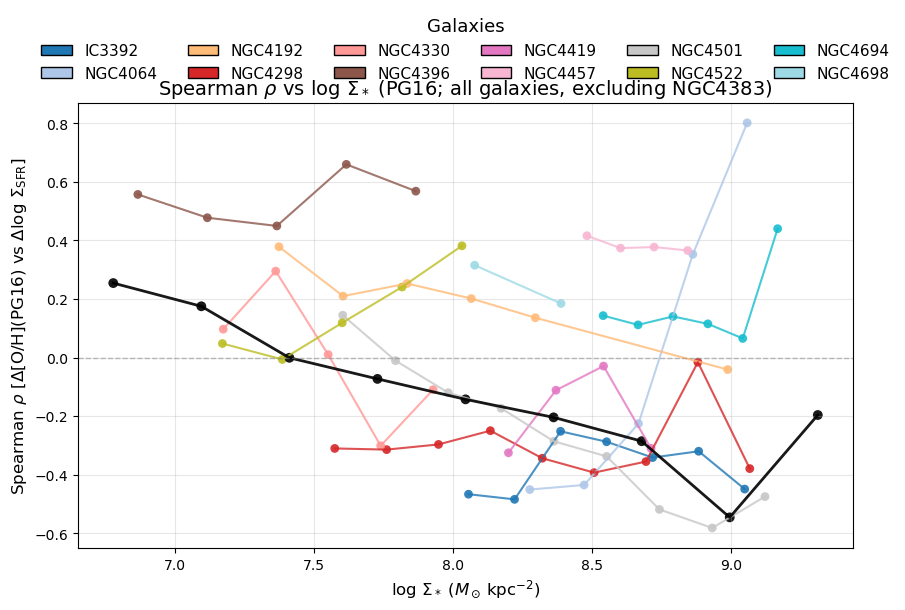

In [12]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (PG16) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (PG16 metallicity)
# ------------------------------------------------------------------
def load_maps_pg16(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_PG16scal_HII' in h_gas:
            oh_map = h_gas['O_H_PG16scal_HII'].data
            indicator_name = 'PG16'
        elif 'O_H_PG16_HII' in h_gas:
            # Fallback in case the scale-specific version is not present
            oh_map = h_gas['O_H_PG16_HII'].data
            indicator_name = 'PG16'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No PG16 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (PG16; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_pg16_map, indicator_name = load_maps_pg16(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_pg16_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_pg16_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_pg16_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (PG16) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, rho=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_pg16_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho={spearman_rho:.3f}")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (no trend or too few in 95%)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy, PG16):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method, PG16)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together, PG16)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, rho=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho={rho_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (PG16)
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H](PG16) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (PG16; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Spearman rho values to plot (PG16).")

Offset relations and Spearman rho vs Σ_* (O3N2-C20; excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...


  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] (O3N2-C20) axis limits: ±0.214
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, rho=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, rho=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, rho=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, rho=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, rho=0.340
    Bin 06 (8.22): n=4888, rho=0.318
    Bin 07 (8.39): n=2989, rho=0.207
    Bin 08 (8.55): n=1266, rho=0.264
    Bin 09 (8.72): n=750, rho=0.160
    Bin 10 (8.88): n=306, rho=0.242
    Bin 11 (9.05): n=131, rho=-0.077
    Bin 12 (9.21): n=33, rho=N/A (no trend or too few in 95%)

Processing NGC4064 ...
  Σ* range: 7.005 to 9.351
  Global Δlog(Σ_SFR) axis limits: ±2.265
  Global Δ[O/H] (O3N2-C20) axis limits: ±0.251
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.10): n=254, rho=N/A (no trend

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_16576/2079941111.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


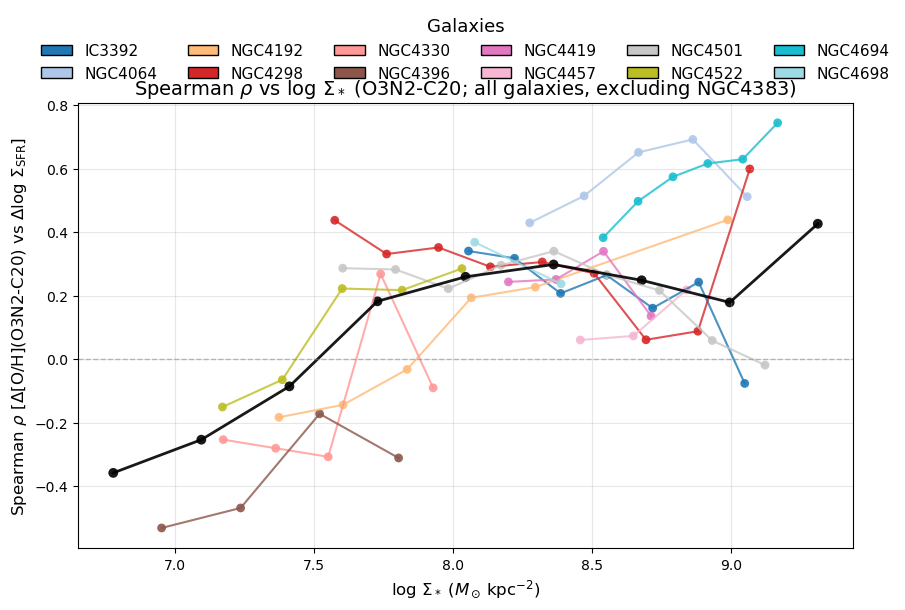

In [13]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] (O3N2-C20) vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps (O3N2-C20 metallicity)
# ------------------------------------------------------------------
def load_maps_o3n2_c20(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_C20_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_C20_HII'].data
            indicator_name = 'O3N2-C20'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2-C20 metallicity extension found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (O3N2-C20; excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_c20_map, indicator_name = load_maps_o3n2_c20(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_c20_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_c20_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_c20_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] (O3N2-C20) axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, rho=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_c20_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho={spearman_rho:.3f}")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, rho=N/A (no trend or too few in 95%)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy, O3N2-C20):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method, O3N2-C20)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together, O3N2-C20)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, rho=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho={rho_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, rho=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black (O3N2-C20)
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H](O3N2-C20) vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (O3N2-C20; all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid Spearman rho values to plot (O3N2-C20).")